In [ ]:
# First filter out the important objects from the data

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion import arcline_path_utils
from nuscenes.map_expansion.bitmap import BitMap
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
from collections import defaultdict, OrderedDict


In [4]:
import os

# Initialize nuScenes dataset
dataroot = os.path.expanduser('~/Desktop/Nuscenes/nuscenes')
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

# Select a scene (first scene)
scene = nusc.scene[2]
first_sample_token = scene['first_sample_token']
sample = nusc.get('sample', first_sample_token)
ego_vehicle_start_time = sample['timestamp']

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.188 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [5]:
scene['description']

'Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller'

In [6]:
sample = nusc.get('sample', first_sample_token)

In [13]:
# Get the correct map for the scene
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot='/Users/liliu/Desktop/Nuscenes/nuscenes', map_name=location)

# Store ego trajectory and object trajectories
ego_trajectory = []
ego_orientations = []
timestamps = []

object_trajectories = defaultdict(list)
object_orientations = defaultdict(list)
object_labels = {}
object_categories = {}  # Store category for each instance

# Function to convert quaternion to 2D yaw angle
def quaternion_to_yaw(quaternion):
    q = Quaternion(quaternion)
    yaw = np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))
    return yaw

# Track object instances separately
object_name_counter = defaultdict(int)

# Loop through all samples in the scene
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)

    # Get timestamp (normalize between 0 and 1 for transparency)
    timestamps.append(sample['timestamp'])

    # Get ego_pose information
    sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Using LiDAR for reference
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    ego_position = tuple(ego_pose['translation'][:2])  # X, Y position
    ego_yaw = quaternion_to_yaw(ego_pose['rotation'])  # Get orientation (yaw)

    ego_trajectory.append(ego_position)
    ego_orientations.append(ego_yaw)

    # Track all objects in the scene
    for ann_token in sample['anns']:
        ann_data = nusc.get('sample_annotation', ann_token)
        instance_token = ann_data['instance_token']
        object_position = tuple(ann_data['translation'][:2])  # Convert to tuple for uniqueness
        object_yaw = quaternion_to_yaw(ann_data['rotation'])  # Get orientation (yaw)

        # Get object category name
        category_name = ann_data['category_name']
        object_categories[instance_token] = category_name  # Store category

        # Differentiate identical objects with numbering (_1, _2, ...)
        if instance_token not in object_labels:
            object_name_counter[category_name] += 1
            unique_name = f"{category_name}_{object_name_counter[category_name]}"  # Append instance number
            object_labels[instance_token] = unique_name

        # Store object trajectory and orientation
        object_trajectories[instance_token].append(object_position)
        object_orientations[instance_token].append(object_yaw)

    # Move to the next sample
    sample_token = sample['next']

# Normalize timestamps for transparency (0 = oldest, 1 = newest)
timestamps = np.array(timestamps)
timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())  # Normalize between 0 and 1

# Convert ego trajectory to NumPy arrays for plotting
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)

### Get the most obvious moving objects (with their unique locations)

In [8]:

# **Count unique locations per object (at ranking stage)**
unique_location_counts = {}
filtered_trajectories = {}
filtered_orientations = {}

for instance_token, trajectory in object_trajectories.items():
    unique_locs = OrderedDict()  # Ensure order and store first occurrence of each location
    for i, loc in enumerate(trajectory):
        if loc not in unique_locs:
            unique_locs[loc] = object_orientations[instance_token][i]  # Store first orientation for each unique loc
    
    unique_location_counts[instance_token] = len(unique_locs)  # Count unique locations
    filtered_trajectories[instance_token] = list(unique_locs.keys())  # Store unique locations
    filtered_orientations[instance_token] = list(unique_locs.values())  # Store linked orientations

# **Sort and filter the top 10 longest unique-location trajectories (including ties)**
sorted_lengths = sorted(set(unique_location_counts.values()), reverse=True)  # Get unique lengths, sorted descending

# Keep all objects with trajectory length in the top 10 unique values
if len(sorted_lengths) > 10:
    threshold_length = sorted_lengths[9]  # Get the 10th longest unique length
    selected_instances = {k for k, v in unique_location_counts.items() if v >= threshold_length}
else:
    selected_instances = set(unique_location_counts.keys())  # If fewer than 10 unique lengths, plot all

In [9]:
selected_instances

{'18cdcf0d2340409b95140ea38a70fd2e',
 '19804c352c0a4767b61b8d0709d1db99',
 '21d4060224a946e5b66fd00749282e82',
 '2397a588f42e4195bf7fb0148aa7a3d6',
 '2e19253f3bac458191cf64ff2b22ba2b',
 '340ccb3c0dcb492eaa032f0e4e3017bb',
 '3993afe444aa4497b1fec37c89fcc369',
 '4f41f55039c34783b0f63a3ebc196434',
 '6ae762f1bc254d00bfb5ae9d66ffe376',
 '6b9c9912fecb4847b93e81eb10da83a2',
 '7c6e078abfa74db5a5439711383a8f5b',
 '888521a8b57f46258e81a89bf062278b',
 '94e0b9b077774f18a74f53c5305a368d',
 '9e94bea2db384cf1ba7264e02920b1d8',
 'afd097377c71479ea8349eeae83b8143',
 'b2a522c239af44e0927a51c941bd256e',
 'b4db00c7834047799104363c10eca351',
 'b61b72a5b5ad482e9bc94c203f75b8d4',
 'bdb82f4d50ce47e6b3925471c049355e',
 'd9a4df9e92804a44a039eb21e0dc1349',
 'e2afd7eaa5c04cff9e59ca025e14249c',
 'e8ee78065abc41ac9dcae839a29eac0b',
 'ecf7d2d3b0984505a33fc612ac350e6b',
 'f442a98a9a354484aef5240bb21e7691',
 'f53b4aa3d74e473c90afb956e618e3ce',
 'fb0b1fa4a33a43ea9cc802ba14a40586'}

## Get the relative location of instance with the Top-ridar's coordinate system (coordinate defined as: X-right, Y-forward)

In [10]:
instance_id = "6ae762f1bc254d00bfb5ae9d66ffe376"
print_debug = False

In [11]:
from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion
import os
from nuscenes.nuscenes import NuScenes


# Precompute ego vehicle positions
def compute_scene_ego_positions(nusc, scene_index):
    scene_ego_positions = {}
    scene = nusc.scene[scene_index]
    first_sample_token = scene['first_sample_token']
    first_sample = nusc.get('sample', first_sample_token)
    ego_vehicle_raw_start_time = first_sample['timestamp'] / 1e6

    sample_token = first_sample_token
    while sample_token:
        sample = nusc.get('sample', sample_token)
        timestamp = sample['timestamp'] / 1e6
        sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
        scene_ego_positions[timestamp] = tuple(ego_pose['translation'][:2])
        sample_token = sample['next']

    return scene_ego_positions, ego_vehicle_raw_start_time

class InstanceFrame:
    """ Class to store and process instance frame information from nuScenes dataset. """
    
    def __init__(self, nusc, instance_token, scene_index, scene_ego_positions, ego_vehicle_raw_start_time):
        """
        Initializes an InstanceFrame object and extracts relevant data.

        Args:
            nusc: NuScenes database instance.
            instance_token: The token of the instance to extract.
            scene_index: The index of the scene in nuScenes dataset.
            scene_ego_positions: Precomputed ego vehicle positions for this scene.
            ego_vehicle_raw_start_time: The raw start timestamp of the ego vehicle (in seconds).
        """
        self.nusc = nusc
        self.instance_token = instance_token
        self.scene_index = scene_index
        self.scene_ego_positions = scene_ego_positions
        self.ego_vehicle_raw_start_time = ego_vehicle_raw_start_time

        # Core attributes
        self.category_name = None
        self.instance_name = None
        self.start_time = None
        self.end_time = None
        self.duration = None
        self.raw_start_time = None
        self.raw_end_time = None
        self.locations = []
        self.orientations = []
        self.sample_tokens = []
        self.scene_token = None

        # Extract information
        self._extract_instance_data()
        self._normalize_times()

    def _extract_instance_data(self):
        """ Extract structured Frame representation for the instance in nuScenes. """

        instance = self.nusc.get('instance', self.instance_token)
        first_ann_token = instance['first_annotation_token']
        
        ann = self.nusc.get('sample_annotation', first_ann_token)
        self.category_name = ann['category_name']

        while ann:
            sample = self.nusc.get('sample', ann['sample_token'])
            timestamp = sample['timestamp'] / 1e6  # Convert to seconds

            if self.start_time is None:
                self.start_time = timestamp
                self.raw_start_time = timestamp
                self.scene_token = sample["scene_token"]

            self.end_time = timestamp
            self.raw_end_time = timestamp

            # Transform annotation from global frame to LiDAR frame
            lidar_translation, lidar_rotation = self._get_lidar_pose(sample['data']['LIDAR_TOP'])
            obj_translation = np.array(ann["translation"])
            obj_rotation = Quaternion(ann["rotation"])

            transformed_translation, transformed_yaw = self._transform_global_to_lidar(
                obj_translation, obj_rotation, lidar_translation, lidar_rotation
            )

            self.locations.append(transformed_translation[:2])  # X, Y in LiDAR frame
            self.orientations.append(transformed_yaw)  # Yaw in LiDAR frame

            self.sample_tokens.append(ann["sample_token"])

            if ann["next"]:
                ann = self.nusc.get("sample_annotation", ann["next"])
            else:
                break

        self.duration = self.end_time - self.start_time

    def _normalize_times(self):
        """ Normalize start and end times relative to the ego vehicle's first timestamp in the scene. """
        self.start_time -= self.ego_vehicle_raw_start_time
        self.end_time -= self.ego_vehicle_raw_start_time

    def _get_lidar_pose(self, lidar_token):
        """ Retrieve the LiDAR position and rotation from ego pose. """
        lidar_data = self.nusc.get('sample_data', lidar_token)
        ego_pose = self.nusc.get('ego_pose', lidar_data['ego_pose_token'])
        return np.array(ego_pose['translation']), Quaternion(ego_pose['rotation'])

    def _transform_global_to_lidar(self, obj_translation, obj_rotation, lidar_translation, lidar_rotation):
        """
        Transform object position and orientation from global frame to the LiDAR frame.
        """
    

    
        # Step 1: Translate to LiDAR's origin
        relative_translation = obj_translation - lidar_translation

    
        # Step 2: Rotate using inverse of LiDAR rotation
        transformed_translation = lidar_rotation.inverse.rotate(relative_translation)
        
        # **Fix the Axis Swapping Issue**
        transformed_translation = np.array([-transformed_translation[1], transformed_translation[0], transformed_translation[2]])
        

        # Step 3: Convert rotation to LiDAR's frame

        transformed_rotation = lidar_rotation.inverse * obj_rotation
        transformed_yaw = np.arctan2(
            2.0 * (transformed_rotation.w * transformed_rotation.z + transformed_rotation.x * transformed_rotation.y),
            1.0 - 2.0 * (transformed_rotation.y**2 + transformed_rotation.z**2)
        )
    

        # Choose whether debug with print
        if print_debug:
            print(f" LiDAR Position: {obj_rotation}")           
            print(f" Global Position: {obj_translation}")
            print(f" LiDAR Position: {lidar_translation}")
            print(f" Relative Position (before rotation): {relative_translation}")
            print(f"✅ Fixed Transformed Position (LiDAR Frame): {transformed_translation}")
            print(f" Original Rotation (Quaternion): {obj_rotation}")
            print(f"✅ Transformed Yaw (LiDAR Frame): {np.degrees(transformed_yaw)} degrees")
    
        return transformed_translation, transformed_yaw


    def _classify_orientation(self, yaw_rad):
        """ Classify the relative orientation in LiDAR frame. """
        yaw_deg = np.degrees(yaw_rad) % 360
        if yaw_deg > 180:
            yaw_deg -= 360  # Normalize to [-180, 180]

        if abs(yaw_deg) < 45:
            return "facing same direction"
        elif abs(yaw_deg - 180) < 45 or abs(yaw_deg + 180) < 45:
            return "facing opposite direction"
        elif 45 <= yaw_deg <= 135:
            return "facing leftward (perpendicular)"
        elif -135 <= yaw_deg <= -45:
            return "facing rightward (perpendicular)"
        else:
            return "heading unclear"



    def describe_movement(self):
        """
        A detailed scenario-based & dominant-direction movement description
        in LiDAR frame (x=right, y=up), considering the **entire trajectory**.
    
        Key features:
        - Describes movement trends over time.
        - Separates Left/Right and Forward/Backward positioning (no center state).
        - Tracks relative positioning with respect to the ego vehicle.
        - Detects crossing events (left↔right, behind↔ahead).
        - Computes movement dominance dynamically.
        - Reports mean and minimum distance to the ego vehicle.
    
        The 'one region' logic: explicitly says "always left/right" or "always behind/ahead"
        if applicable.



        TODO: 
              1. We take the relative distances as the trajectory distance (which might not be the same as the actual path length, according to the ego vehicle).
        """
    
        if len(self.locations) < 2:
            return "Not enough data to describe movement."
    
        distances_to_ego = [np.linalg.norm(loc) for loc in self.locations]
        mean_distance = np.mean(distances_to_ego)
        min_distance = np.min(distances_to_ego)

        movement_segments = []
        heading_segments = []
        segment_changes_lr = []
        segment_changes_fb = []
        relative_lr = []
        relative_fb = []
        total_distance = 0

        prev_x, prev_y = self.locations[0]

        for i in range(1, len(self.locations)):
            cur_x, cur_y = self.locations[i]
            dx, dy = cur_x - prev_x, cur_y - prev_y
            distance = np.hypot(dx, dy)
            total_distance += distance

            # --- Movement direction ---
            if distance < 0.5:
                move_desc = "had minor movement"
            else:
                abs_dx, abs_dy = abs(dx), abs(dy)
                ratio = abs_dx / abs_dy if abs_dy > 1e-6 else float('inf')
                if ratio > 1.5:
                    move_desc = "moved dominantly right" if dx > 0 else "moved dominantly left"
                elif ratio < 0.66:
                    move_desc = "moved dominantly forward" if dy > 0 else "moved dominantly backward"
                else:
                    move_desc = "moved diagonally"
            movement_segments.append(move_desc)

            # --- Orientation status ---
            heading_segments.append(self._classify_orientation(self.orientations[i]))

            # --- Relative lateral / longitudinal position ---
            cur_lr = "left" if cur_x < 0 else "right"
            cur_fb = "behind" if cur_y < 0 else "ahead"

            if i > 1:
                prev_lr, prev_fb = relative_lr[-1], relative_fb[-1]
                if prev_lr != cur_lr:
                    segment_changes_lr.append(f"crossed from {prev_lr} to {cur_lr}")
                if prev_fb != cur_fb:
                    segment_changes_fb.append(f"crossed from {prev_fb} to {cur_fb}")

            relative_lr.append(cur_lr)
            relative_fb.append(cur_fb)

            prev_x, prev_y = cur_x, cur_y

        movement_trend = ", then ".join(dict.fromkeys(movement_segments))
        heading_trend = ", then ".join(dict.fromkeys(heading_segments))

        # Position summaries
        lr_summary = (
            f"always {relative_lr[0]}" if len(set(relative_lr)) == 1 else
            ", ".join(dict.fromkeys(segment_changes_lr)) if segment_changes_lr else
            "exhibited partial left/right shifts"
        )
        fb_summary = (
            f"always {relative_fb[0]}" if len(set(relative_fb)) == 1 else
            ", ".join(dict.fromkeys(segment_changes_fb)) if segment_changes_fb else
            "exhibited partial forward/back shifts"
        )

        return (
            f"A {self.category_name} {movement_trend}. "
            f"Relative to the ego vehicle, it was {lr_summary} laterally "
            f"and {fb_summary} longitudinally. "
            f"It covered a total distance of approximately {total_distance:.2f}m over {self.duration:.2f}s. "
            f"Mean distance: {mean_distance:.2f}m, closest approach: {min_distance:.2f}m. "
            f"Its orientation over time was: {heading_trend}."
        )





    def to_dict(self):
        """ Converts the instance frame object to a dictionary for easy usage. """
        return {
            "instance_token": self.instance_token,
            "category_name": self.category_name,
            "instance_name": self.instance_name,
            "raw_start_time": self.raw_start_time,
            "raw_end_time": self.raw_end_time,
            "ego_vehicle_raw_start_time": self.ego_vehicle_raw_start_time,
            "start_time": self.start_time,
            "end_time": self.end_time,
            "duration": self.duration,
            "locations": self.locations,
            "orientations": self.orientations,
            "sample_tokens": self.sample_tokens,
            "scene_token": self.scene_token,
            "description": self.describe_movement()
        }

# Example usage:
# scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
# instance_frame = InstanceFrame(nusc, instance_id, 2, scene_ego_positions, ego_vehicle_raw_start_time)#888521a8b57f46258e81a89bf062278b
# print(instance_frame.to_dict())

In [18]:
scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
instance_descriptions = []
for instance_id in selected_instances:
    instance_frame = InstanceFrame(nusc, instance_id, 2, scene_ego_positions, ego_vehicle_raw_start_time)
    print('instance_id:', instance_id)
    print(instance_frame.describe_movement())
    print("\n")
    instance_descriptions.append(instance_frame.describe_movement())

instance_id: bdb82f4d50ce47e6b3925471c049355e
A vehicle.car had minor movement. Relative to the ego vehicle, it was always left laterally and always ahead longitudinally. It covered a total distance of approximately 0.43m over 12.85s. Mean distance: 81.58m, closest approach: 81.44m. Its orientation over time was: facing leftward (perpendicular).


instance_id: ecf7d2d3b0984505a33fc612ac350e6b
A movable_object.pushable_pullable moved dominantly right, then had minor movement, then moved diagonally. Relative to the ego vehicle, it was crossed from left to right laterally and always ahead longitudinally. It covered a total distance of approximately 21.79m over 19.90s. Mean distance: 11.33m, closest approach: 9.33m. Its orientation over time was: facing rightward (perpendicular).


instance_id: 6ae762f1bc254d00bfb5ae9d66ffe376
A vehicle.car had minor movement. Relative to the ego vehicle, it was always left laterally and always behind longitudinally. It covered a total distance of approxim

In [20]:
overall_description = ''.join(instance_descriptions)

In [29]:
overall_description

'A vehicle.car had minor movement. Relative to the ego vehicle, it was always left laterally and always ahead longitudinally. It covered a total distance of approximately 0.43m over 12.85s. Mean distance: 81.58m, closest approach: 81.44m. Its orientation over time was: facing leftward (perpendicular).A movable_object.pushable_pullable moved dominantly right, then had minor movement, then moved diagonally. Relative to the ego vehicle, it was crossed from left to right laterally and always ahead longitudinally. It covered a total distance of approximately 21.79m over 19.90s. Mean distance: 11.33m, closest approach: 9.33m. Its orientation over time was: facing rightward (perpendicular).A vehicle.car had minor movement. Relative to the ego vehicle, it was always left laterally and always behind longitudinally. It covered a total distance of approximately 0.04m over 19.90s. Mean distance: 7.03m, closest approach: 7.02m. Its orientation over time was: facing same direction.A vehicle.car move

In [30]:
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input=f"Write a one-sentence summary about the scene, identify specific important objects in autonomous driving scenarios:{overall_description}."
)

print(response.output_text)

In a complex autonomous driving scenario, multiple objects including cars, pedestrians, and barriers exhibited varied movements and orientations relative to the ego vehicle, with significant interactions characterized by distances covered, closest approaches, and lateral positioning, highlighting the need for advanced perception and navigation systems to ensure safety and efficiency.


In [23]:
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input=f"Write a one-sentence summary about the scene, identify specific important objects in autonomous driving scenarios:{overall_description}. You should output the summary like {nusc.scene[1]['description']}. "
)

print(response.output_text)

Many peds right, moving laterally, wait for turning cars, with long distances from behind, and significant initial movements from various vehicles, including cars and a truck, moving mostly right.


In [25]:
nusc.scene[2]['description']

'Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller'

Check this id "instance_id = '2e19253f3bac458191cf64ff2b22ba2b'". A bus turnning left

In [26]:
instance_id = '2e19253f3bac458191cf64ff2b22ba2b'

In [27]:
instance_frame = InstanceFrame(nusc, instance_id, 2, scene_ego_positions, ego_vehicle_raw_start_time)
print('instance_id:', instance_id)
print(instance_frame.describe_movement())

instance_id: 2e19253f3bac458191cf64ff2b22ba2b
A vehicle.bus.rigid had minor movement, then moved dominantly right, then moved diagonally, then moved dominantly forward. Relative to the ego vehicle, it was always left laterally and always ahead longitudinally. It covered a total distance of approximately 134.36m over 19.40s. Mean distance: 63.99m, closest approach: 32.25m. Its orientation over time was: facing rightward (perpendicular), then facing same direction.


In [32]:
instance_frame.to_dict()

{'instance_token': '2e19253f3bac458191cf64ff2b22ba2b',
 'category_name': 'vehicle.bus.rigid',
 'instance_name': None,
 'raw_start_time': 1535489296.047917,
 'raw_end_time': 1535489315.448527,
 'ego_vehicle_raw_start_time': 1535489296.047917,
 'start_time': 0.0,
 'end_time': 19.400610208511353,
 'duration': 19.400610208511353,
 'locations': [array([-41.39302489,  25.84052041]),
  array([-41.01805339,  25.90947553]),
  array([-40.27430915,  25.94049756]),
  array([-39.29866454,  25.97785835]),
  array([-37.81527067,  25.81334895]),
  array([-36.02883872,  25.75784302]),
  array([-33.41980422,  25.90114807]),
  array([-30.80895467,  26.04726998]),
  array([-28.19691187,  26.19376146]),
  array([-25.27566933,  26.07447448]),
  array([-22.09056395,  26.56023335]),
  array([-19.38755614,  27.12155665]),
  array([-16.69460329,  27.83659323]),
  array([-14.23350576,  28.93731814]),
  array([-12.07446046,  30.31555699]),
  array([-10.17851495,  32.09579253]),
  array([-8.32752428, 34.26186996])

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.308 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


/opt/anaconda3/envs/nuscenes/lib/python3.9/site-packages/descartes/patch.py:62: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  vertices = concatenate([
/opt/anaconda3/envs/nuscenes/lib/python3.9/site-packages/descartes/patch.py:64: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  [asarray(r)[:, :2] for r in t.interiors])


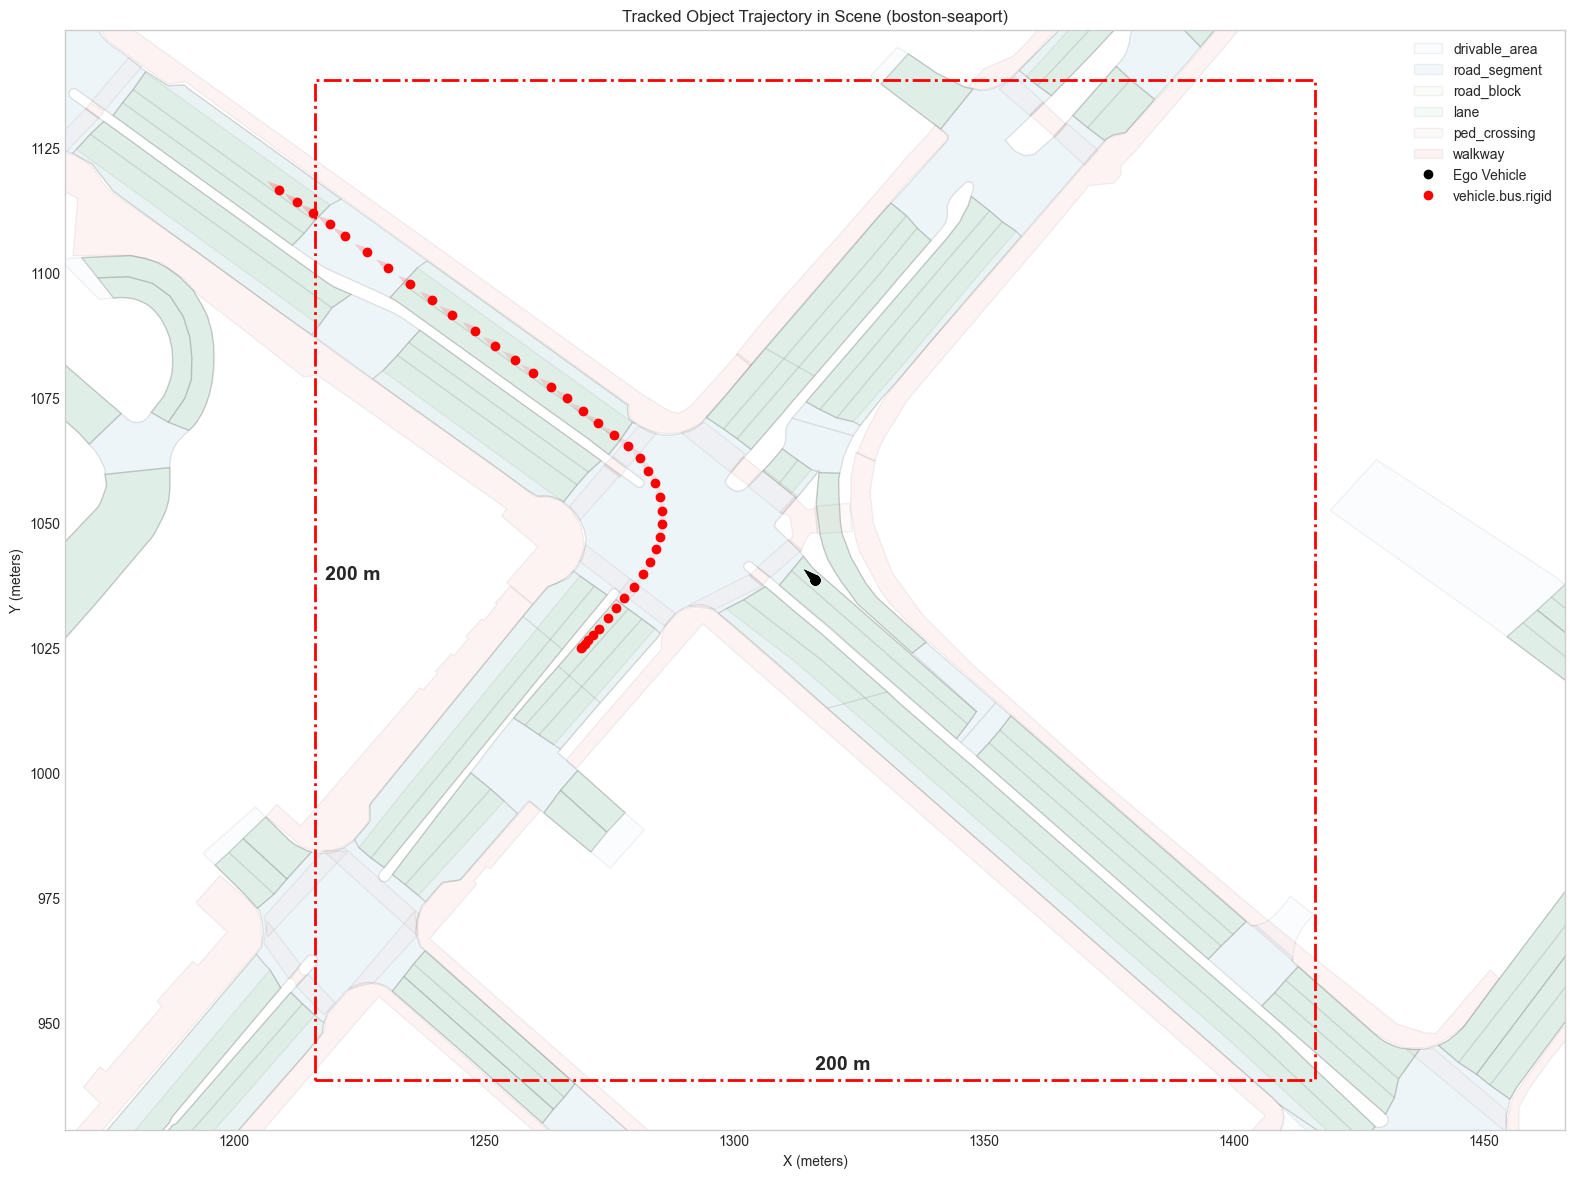

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict, OrderedDict
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# Toggle to control arrow display (set to False to hide arrows)
show_arrows = True

# Step 1: Load nuScenes dataset
dataroot = "/Users/liliu/Desktop/Nuscenes/nuscenes"  # Adjust this path as needed
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

# Step 2: Define the scene and the instance you want to visualize
scene_index = 2  # Adjust this to your scene index
instance_token = instance_id  # Replace with the actual instance token

# Step 3: Load scene and map
scene = nusc.scene[scene_index]
first_sample_token = scene['first_sample_token']
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot=dataroot, map_name=location)

# Step 4: Function to convert quaternion to yaw
def quaternion_to_yaw(quaternion):
    q = Quaternion(quaternion)
    return np.arctan2(2.0*(q.w*q.z + q.x*q.y), 1.0 - 2.0*(q.y*q.y + q.z*q.z))

# Step 5: Store trajectories
ego_trajectory = []
ego_orientations = []
timestamps = []
object_trajectory = []
object_orientations = []

# Step 6: Loop through all samples in the scene
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)
    timestamps.append(sample['timestamp'])
    
    # Get ego vehicle pose using LIDAR_TOP
    sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    ego_trajectory.append(tuple(ego_pose['translation'][:2]))  # X, Y position
    ego_orientations.append(quaternion_to_yaw(ego_pose['rotation']))
    
    # Process all objects in the scene; only consider the specified instance
    for ann_token in sample['anns']:
        ann_data = nusc.get('sample_annotation', ann_token)
        if ann_data['instance_token'] == instance_token:
            object_trajectory.append(tuple(ann_data['translation'][:2]))
            object_orientations.append(quaternion_to_yaw(ann_data['rotation']))
    
    sample_token = sample['next']

# Step 7: Normalize timestamps
timestamps = np.array(timestamps)
timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())

# Step 8: Convert lists to NumPy arrays
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)
object_trajectory = np.array(object_trajectory)
object_orientations = np.array(object_orientations)

# Step 9: Determine map bounds
x_min, y_min = np.min(ego_trajectory, axis=0) - 100
x_max, y_max = np.max(ego_trajectory, axis=0) + 100
map_bounds = (x_min, y_min, x_max, y_max)

# Step 10: Define map layers
layer_names = ["drivable_area", "road_segment", "road_block", "lane", "ped_crossing", "walkway"]

# Step 11: Render the map patch with 50% transparency
fig, ax = nusc_map.render_map_patch(map_bounds, layer_names, alpha=0.05)
ax.set_aspect('equal')

# Step 12: Plot ego vehicle trajectory in black and add arrows (if enabled)
ax.plot(ego_trajectory[:, 0], ego_trajectory[:, 1], 'o', color="black", label="Ego Vehicle")
if show_arrows:
    for i in range(len(ego_trajectory)):
        alpha = timestamps[i]
        dx = 3 * np.cos(ego_orientations[i])
        dy = 3 * np.sin(ego_orientations[i])
        ax.quiver(ego_trajectory[i, 0], ego_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(0,0,0,0.2*alpha))

# Step 13: Plot object trajectory in red and add arrows (if enabled)
ax.plot(object_trajectory[:, 0], object_trajectory[:, 1], 'o', color="red", label=f"{instance_frame.category_name}")
if show_arrows:
    for i in range(len(object_trajectory)):
        alpha = timestamps[i]
        dx = 3 * np.cos(object_orientations[i])
        dy = 3 * np.sin(object_orientations[i])
        ax.quiver(object_trajectory[i, 0], object_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(1,0,0,0.2*alpha))

# Step 14: Labels and legend
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Tracked Object Trajectory in Scene ({location})")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# from collections import defaultdict, OrderedDict
# import numpy as np
# from pyquaternion import Quaternion
# import os
# from nuscenes.nuscenes import NuScenes

# class InstanceFrame:
#     """ Class to store and process instance frame information from nuScenes dataset. """
    
#     def __init__(self, nusc, instance_token, scene_index, scene_ego_positions, ego_vehicle_raw_start_time):
#         """
#         Initializes an InstanceFrame object and extracts relevant data.

#         Args:
#             nusc: NuScenes database instance.
#             instance_token: The token of the instance to extract.
#             scene_index: The index of the scene in nuScenes dataset.
#             scene_ego_positions: Precomputed ego vehicle positions for this scene.
#             ego_vehicle_raw_start_time: The raw start timestamp of the ego vehicle (in seconds).
#         """
#         self.nusc = nusc
#         self.instance_token = instance_token
#         self.scene_index = scene_index
#         self.scene_ego_positions = scene_ego_positions
#         self.ego_vehicle_raw_start_time = ego_vehicle_raw_start_time  # New feature

#         # Core attributes
#         self.category_name = None
#         self.instance_name = None
#         self.start_time = None
#         self.end_time = None
#         self.duration = None
#         self.raw_start_time = None
#         self.raw_end_time = None
#         self.locations = []
#         self.orientations = []
#         self.sample_tokens = []
#         self.scene_token = None
#         self.relative_movements = []

#         # Extract information
#         self._extract_instance_data()
#         self._normalize_times()
#         self._compute_relative_movement()

#     def _extract_instance_data(self):
#         """ Extract structured Frame representation for the instance in nuScenes. """

#         instance = self.nusc.get('instance', self.instance_token)
#         first_ann_token = instance['first_annotation_token']
        
#         ann = self.nusc.get('sample_annotation', first_ann_token)
#         self.category_name = ann['category_name']

#         while ann:
#             sample = self.nusc.get('sample', ann['sample_token'])
#             timestamp = sample['timestamp'] / 1e6  # Convert to seconds

#             if self.start_time is None:
#                 self.start_time = timestamp
#                 self.raw_start_time = timestamp
#                 self.scene_token = sample["scene_token"]

#             self.end_time = timestamp
#             self.raw_end_time = timestamp

#             # Transform annotation from global frame to LiDAR frame
#             lidar_translation, lidar_rotation = self._get_lidar_pose(sample['data']['LIDAR_TOP'])
#             obj_translation = np.array(ann["translation"])
#             obj_rotation = Quaternion(ann["rotation"])

#             transformed_translation, transformed_yaw = self._transform_global_to_lidar(
#                 obj_translation, obj_rotation, lidar_translation, lidar_rotation
#             )

#             self.locations.append(transformed_translation[:2])  # X, Y in LiDAR frame
#             self.orientations.append(transformed_yaw)  # Yaw in LiDAR frame

#             self.sample_tokens.append(ann["sample_token"])

#             if ann["next"]:
#                 ann = self.nusc.get("sample_annotation", ann["next"])
#             else:
#                 break

#         self.duration = self.end_time - self.start_time

#     def _normalize_times(self):
#         """ Normalize start and end times relative to the ego vehicle's first timestamp in the scene. """
#         self.start_time -= self.ego_vehicle_raw_start_time
#         self.end_time -= self.ego_vehicle_raw_start_time

#     def _compute_relative_movement(self):
#         """ Compute the relative movement of the instance with respect to the ego vehicle using precomputed positions. """
#         for i, (timestamp, location) in enumerate(zip(np.linspace(self.start_time, self.end_time, len(self.locations)), self.locations)):
#             closest_ego_time = min(self.scene_ego_positions.keys(), key=lambda t: abs(t - timestamp))
#             ego_x, ego_y = self.scene_ego_positions[closest_ego_time]
#             obj_x, obj_y = location
#             rel_x, rel_y = obj_x - ego_x, obj_y - ego_y

#             self.relative_movements.append((rel_x, rel_y))

#     def _get_lidar_pose(self, lidar_token):
#         """ Retrieve the LiDAR position and rotation from ego pose. """
#         lidar_data = self.nusc.get('sample_data', lidar_token)
#         ego_pose = self.nusc.get('ego_pose', lidar_data['ego_pose_token'])
#         return np.array(ego_pose['translation']), Quaternion(ego_pose['rotation'])

#     def _transform_global_to_lidar(self, obj_translation, obj_rotation, lidar_translation, lidar_rotation):
#         """
#         Transform object position and orientation from global frame to the LiDAR frame.

#         Args:
#             obj_translation: Object position in global coordinates.
#             obj_rotation: Object orientation in global coordinates (quaternion).
#             lidar_translation: LiDAR position in global coordinates.
#             lidar_rotation: LiDAR orientation in global coordinates (quaternion).

#         Returns:
#             Transformed position and yaw in LiDAR frame.
#         """
#         # Step 1: Translate to LiDAR's origin
#         relative_translation = obj_translation - lidar_translation

#         # Step 2: Rotate using inverse of LiDAR rotation
#         transformed_translation = lidar_rotation.inverse.rotate(relative_translation)

#         # Step 3: Convert rotation to LiDAR's frame
#         transformed_rotation = lidar_rotation.inverse * obj_rotation
#         transformed_yaw = np.arctan2(2.0 * (transformed_rotation.w * transformed_rotation.z + transformed_rotation.x * transformed_rotation.y),
#                                       1.0 - 2.0 * (transformed_rotation.y**2 + transformed_rotation.z**2))

#         return transformed_translation, transformed_yaw

#     def to_dict(self):
#         """ Converts the instance frame object to a dictionary for easy usage. """
#         return {
#             "instance_token": self.instance_token,
#             "category_name": self.category_name,
#             "instance_name": self.instance_name,
#             "raw_start_time": self.raw_start_time,
#             "raw_end_time": self.raw_end_time,
#             "ego_vehicle_raw_start_time": self.ego_vehicle_raw_start_time,
#             "start_time": self.start_time,
#             "end_time": self.end_time,
#             "duration": self.duration,
#             "locations": self.locations,
#             "orientations": self.orientations,
#             "sample_tokens": self.sample_tokens,
#             "scene_token": self.scene_token,
#             "description": self.describe_movement()
#         }
#     def describe_movement(self):
#         """ 
#         Generate a natural language description of the instance's movement relative to the Top LiDAR frame.
#         The Top LiDAR frame has Y-axis forward and X-axis right.
#         """
#         if len(self.relative_movements) < 2:
#             return "Not enough data to describe movement."
    
#         # Compute total displacement in LiDAR frame
#         start_x, start_y = self.relative_movements[0]
#         end_x, end_y = self.relative_movements[-1]
#         displacement = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)
    
#         # Compute direction based on displacement
#         movement_x = end_x - start_x  # X is right in LiDAR frame
#         movement_y = end_y - start_y  # Y is forward in LiDAR frame
#         angle = np.arctan2(movement_y, movement_x)  # Angle relative to LiDAR frame
    
#         # Classify movement based on correct angle ranges
#         if np.pi / 3 <= angle <= 2 * np.pi / 3:  # Close to π/2 → Forward
#             direction = "moved forward"
#         elif 0 <= angle < np.pi / 3:  # Close to 0 → Right
#             direction = "moved rightward"
#         elif -np.pi / 3 < angle < 0:  # Close to 0 but negative → Slightly right
#             direction = "turned slightly right"
#         elif 2 * np.pi / 3 < angle <= np.pi or -np.pi <= angle < -2 * np.pi / 3:  # Close to π → Left
#             direction = "moved leftward"
#         elif -2 * np.pi / 3 <= angle <= -np.pi / 3:  # Close to -π/2 → Backward
#             direction = "moved backward"
#         else:
#             direction = "remained stationary"
    
#         return f"A {self.category_name} {direction} for {self.duration:.2f} seconds, covering a distance of {displacement:.2f} meters."

# # Precompute ego vehicle positions
# def compute_scene_ego_positions(nusc, scene_index):
#     scene_ego_positions = {}
#     scene = nusc.scene[scene_index]
#     first_sample_token = scene['first_sample_token']
#     first_sample = nusc.get('sample', first_sample_token)
#     ego_vehicle_raw_start_time = first_sample['timestamp'] / 1e6

#     sample_token = first_sample_token
#     while sample_token:
#         sample = nusc.get('sample', sample_token)
#         timestamp = sample['timestamp'] / 1e6
#         sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
#         ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
#         scene_ego_positions[timestamp] = tuple(ego_pose['translation'][:2])
#         sample_token = sample['next']

#     return scene_ego_positions, ego_vehicle_raw_start_time

# # Example usage:
# scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
# instance_frame = InstanceFrame(nusc, "888521a8b57f46258e81a89bf062278b", 2, scene_ego_positions, ego_vehicle_raw_start_time)
# print(instance_frame.to_dict()) 

{'instance_token': '888521a8b57f46258e81a89bf062278b', 'category_name': 'vehicle.car', 'instance_name': None, 'raw_start_time': 1535489296.047917, 'raw_end_time': 1535489315.948406, 'ego_vehicle_raw_start_time': 1535489296.047917, 'start_time': 0.0, 'end_time': 19.90048909187317, 'duration': 19.90048909187317, 'locations': [array([151.98515625,  27.66317686]), array([147.16876166,  27.03174783]), array([141.74551579,  26.27910508]), array([135.37487082,  25.28004979]), array([129.45166064,  24.71434231]), array([123.76363519,  23.96361656]), array([118.07069182,  23.23419286]), array([111.5393261 ,  22.53907209]), array([105.89753797,  21.54044728]), array([101.08993456,  20.70562108]), array([96.27375605, 19.87703705]), array([91.4669799 , 19.03717392]), array([86.65470794, 18.21756506]), array([81.83588498, 17.41185162]), array([77.33662013, 16.67825494]), array([73.51539955, 16.04144049]), array([68.73592005, 15.2481983 ]), array([64.89442778, 14.71759735]), array([61.05062211, 14.1

In [107]:
instance_frame.describe_movement()

'A vehicle.car is approaching & right over 19.90 seconds, covering a total displacement of 104.14 meters.'

In [ ]:
# Rotate with the coordinates of North as the yaw angle (taking the upper LiDAR sensor as reference and by default the Y-axis is forward and the X-axis is right)



from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion
import os
from nuscenes.nuscenes import NuScenes

class InstanceFrame:
    """ Class to store and process instance frame information from nuScenes dataset. """
    
    def __init__(self, nusc, instance_token, scene_index, scene_ego_positions, ego_vehicle_raw_start_time):
        """
        Initializes an InstanceFrame object and extracts relevant data.

        Args:
            nusc: NuScenes database instance.
            instance_token: The token of the instance to extract.
            scene_index: The index of the scene in nuScenes dataset.
            scene_ego_positions: Precomputed ego vehicle positions for this scene.
            ego_vehicle_raw_start_time: The raw start timestamp of the ego vehicle (in seconds).
        """
        self.nusc = nusc
        self.instance_token = instance_token
        self.scene_index = scene_index
        self.scene_ego_positions = scene_ego_positions
        self.ego_vehicle_raw_start_time = ego_vehicle_raw_start_time

        # Core attributes
        self.category_name = None
        self.instance_name = None
        self.start_time = None
        self.end_time = None
        self.duration = None
        self.raw_start_time = None
        self.raw_end_time = None
        self.locations = []
        self.orientations = []
        self.sample_tokens = []
        self.scene_token = None

        # Extract information
        self._extract_instance_data()
        self._normalize_times()

    def _extract_instance_data(self):
        """ Extract structured Frame representation for the instance in nuScenes. """

        instance = self.nusc.get('instance', self.instance_token)
        first_ann_token = instance['first_annotation_token']
        
        ann = self.nusc.get('sample_annotation', first_ann_token)
        self.category_name = ann['category_name']

        while ann:
            sample = self.nusc.get('sample', ann['sample_token'])
            timestamp = sample['timestamp'] / 1e6  # Convert to seconds

            if self.start_time is None:
                self.start_time = timestamp
                self.raw_start_time = timestamp
                self.scene_token = sample["scene_token"]

            self.end_time = timestamp
            self.raw_end_time = timestamp

            # Transform annotation from global frame to LiDAR frame
            lidar_translation, lidar_rotation = self._get_lidar_pose(sample['data']['LIDAR_TOP'])
            obj_translation = np.array(ann["translation"])
            obj_rotation = Quaternion(ann["rotation"])

            transformed_translation, transformed_yaw = self._transform_global_to_lidar(
                obj_translation, obj_rotation, lidar_translation, lidar_rotation
            )

            self.locations.append(transformed_translation[:2])  # X, Y in LiDAR frame
            self.orientations.append(transformed_yaw)  # Yaw in LiDAR frame

            self.sample_tokens.append(ann["sample_token"])

            if ann["next"]:
                ann = self.nusc.get("sample_annotation", ann["next"])
            else:
                break

        self.duration = self.end_time - self.start_time

    def _normalize_times(self):
        """ Normalize start and end times relative to the ego vehicle's first timestamp in the scene. """
        self.start_time -= self.ego_vehicle_raw_start_time
        self.end_time -= self.ego_vehicle_raw_start_time

    def _get_lidar_pose(self, lidar_token):
        """ Retrieve the LiDAR position and rotation from ego pose. """
        lidar_data = self.nusc.get('sample_data', lidar_token)
        ego_pose = self.nusc.get('ego_pose', lidar_data['ego_pose_token'])
        return np.array(ego_pose['translation']), Quaternion(ego_pose['rotation'])

    def _transform_global_to_lidar(self, obj_translation, obj_rotation, lidar_translation, lidar_rotation):
        """
        Transform object position and orientation from global frame to the LiDAR frame.
        """
    
        print(f" Global Position: {obj_translation}")
        print(f" LiDAR Position: {lidar_translation}")
    
        # Step 1: Translate to LiDAR's origin
        relative_translation = obj_translation - lidar_translation
        print(f" Relative Position (before rotation): {relative_translation}")
    
        # Step 2: Rotate using inverse of LiDAR rotation
        transformed_translation = lidar_rotation.inverse.rotate(relative_translation)
        
        # 🚨 **Fix the Axis Swapping Issue**
        transformed_translation = np.array([-transformed_translation[1], transformed_translation[0], transformed_translation[2]])
    
        print(f"✅ Fixed Transformed Position (LiDAR Frame): {transformed_translation}")
    
        # Step 3: Convert rotation to LiDAR's frame
        print(f" LiDAR Position: {obj_rotation}")
        transformed_rotation = lidar_rotation.inverse * obj_rotation
        transformed_yaw = np.arctan2(
            2.0 * (transformed_rotation.w * transformed_rotation.z + transformed_rotation.x * transformed_rotation.y),
            1.0 - 2.0 * (transformed_rotation.y**2 + transformed_rotation.z**2)
        )
    
        print(f" Original Rotation (Quaternion): {obj_rotation}")
        print(f"✅ Transformed Yaw (LiDAR Frame): {np.degrees(transformed_yaw)} degrees")
    
        return transformed_translation, transformed_yaw

    def describe_movement(self):
        """ 
        Generate a natural language description of the instance's movement relative to the Top LiDAR frame.
        The Top LiDAR frame has Y-axis forward and X-axis right.
        """
        if len(self.locations) < 2:
            return "Not enough data to describe movement."

        # Compute total displacement in LiDAR frame
        start_x, start_y = self.locations[0]  # First position in LiDAR frame
        end_x, end_y = self.locations[-1]  # Last position in LiDAR frame
        displacement = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)

        # Compute direction based on displacement
        movement_x = end_x - start_x  # X is right in LiDAR frame
        movement_y = end_y - start_y  # Y is forward in LiDAR frame
        angle = np.arctan2(movement_y, movement_x)  # Angle relative to LiDAR frame

        # Classify movement based on correct angle ranges
        if np.pi / 3 <= angle <= 2 * np.pi / 3:  # Close to π/2 → Forward
            direction = "moved forward"
        elif 0 <= angle < np.pi / 3:  # Close to 0 → Right
            direction = "moved rightward"
        elif -np.pi / 3 < angle < 0:  # Close to 0 but negative → Slightly right
            direction = "turned slightly right"
        elif 2 * np.pi / 3 < angle <= np.pi or -np.pi <= angle < -2 * np.pi / 3:  # Close to π → Left
            direction = "moved leftward"
        elif -2 * np.pi / 3 <= angle <= -np.pi / 3:  # Close to -π/2 → Backward
            direction = "moved backward"
        else:
            direction = "remained stationary"

        return f"A {self.category_name} {direction} for {self.duration:.2f} seconds, covering a distance of {displacement:.2f} meters."

    def to_dict(self):
        """ Converts the instance frame object to a dictionary for easy usage. """
        return {
            "instance_token": self.instance_token,
            "category_name": self.category_name,
            "instance_name": self.instance_name,
            "raw_start_time": self.raw_start_time,
            "raw_end_time": self.raw_end_time,
            "ego_vehicle_raw_start_time": self.ego_vehicle_raw_start_time,
            "start_time": self.start_time,
            "end_time": self.end_time,
            "duration": self.duration,
            "locations": self.locations,
            "orientations": self.orientations,
            "sample_tokens": self.sample_tokens,
            "scene_token": self.scene_token,
            "description": self.describe_movement()
        }

# Example usage:
scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
instance_frame = InstanceFrame(nusc, "888521a8b57f46258e81a89bf062278b", 2, scene_ego_positions, ego_vehicle_raw_start_time)
print(instance_frame.to_dict())

In [103]:
instance_frame.locations

[array([-27.66317686, 151.98515625]),
 array([-27.03174783, 147.16876166]),
 array([-26.27910508, 141.74551579]),
 array([-25.28004979, 135.37487082]),
 array([-24.71434231, 129.45166064]),
 array([-23.96361656, 123.76363519]),
 array([-23.23419286, 118.07069182]),
 array([-22.53907209, 111.5393261 ]),
 array([-21.54044728, 105.89753797]),
 array([-20.70562108, 101.08993456]),
 array([-19.87703705,  96.27375605]),
 array([-19.03717392,  91.4669799 ]),
 array([-18.21756506,  86.65470794]),
 array([-17.41185162,  81.83588498]),
 array([-16.67825494,  77.33662013]),
 array([-16.04144049,  73.51539955]),
 array([-15.2481983 ,  68.73592005]),
 array([-14.71759735,  64.89442778]),
 array([-14.17878856,  61.05062211]),
 array([-13.65271668,  57.20804513]),
 array([-13.31451009,  54.42530173]),
 array([-12.92026339,  51.65270319]),
 array([-12.7375645 ,  50.40814629]),
 array([-12.55789745,  49.16531998]),
 array([-12.57110903,  49.17698511]),
 array([-12.55441633,  49.08196468]),
 array([-12.

In [ ]:
    def describe_movement(self):
        """ 
        Generate a natural language description of the instance's movement relative to the Top LiDAR frame.
        The Top LiDAR frame has Y-axis forward and X-axis right.
        """
        if len(self.locations) < 2:
            return "Not enough data to describe movement."

        # Compute total displacement in LiDAR frame
        start_x, start_y = self.locations[0]  # First position in LiDAR frame
        end_x, end_y = self.locations[-1]  # Last position in LiDAR frame
        displacement = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)

        # Compute direction based on displacement
        movement_x = end_x - start_x  # X is right in LiDAR frame
        movement_y = end_y - start_y  # Y is forward in LiDAR frame
        angle = np.arctan2(movement_y, movement_x)  # Angle relative to LiDAR frame

        # Classify movement based on correct angle ranges
        if np.pi / 3 <= angle <= 2 * np.pi / 3:  # Close to π/2 → Forward
            direction = "moved straight forward"
        elif 0 <= angle < np.pi / 3:  # Close to 0 → Right
            direction = "moved rightward"
        elif -np.pi / 3 < angle < 0:  # Close to 0 but negative → Slightly right
            direction = "turned slightly right"
        elif 2 * np.pi / 3 < angle <= np.pi or -np.pi <= angle < -2 * np.pi / 3:  # Close to π → Left
            direction = "moved leftward"
        elif -2 * np.pi / 3 <= angle <= -np.pi / 3:  # Close to -π/2 → Backward
            direction = "moved backward"
        else:
            direction = "remained stationary"

        return f"A {self.category_name} {direction} for {self.duration:.2f} seconds, covering a distance of {displacement:.2f} meters."

In [104]:
start_x, start_y = instance_frame.locations[0]  # First position in LiDAR frame
end_x, end_y = instance_frame.locations[-1]  # Last position in LiDAR frame
displacement = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)

movement_x = end_x - start_x  # X is right in LiDAR frame
movement_y = end_y - start_y  # Y is forward in LiDAR frame
angle = np.arctan2(movement_y, movement_x)  # Angle relative to LiDAR frame

In [105]:
movement_x, movement_y, angle, np.degrees(angle), displacement

(15.09128555198009,
 -103.03727554844147,
 -1.4253660275856601,
 -81.667457641986,
 104.13657883787452)

In [93]:
import numpy as np

def transform_global_to_ego(obj_xy, ego_xy, ego_yaw):
    """
    Transform obj from global (x=right, y=up) to ego frame (x=right,y=up),
    removing ego's yaw so that ego faces 'straight up' in its own coordinates.
    
    Args:
      obj_xy:  (x_obj, y_obj) in global coords (x=right, y=up)
      ego_xy:  (x_ego, y_ego) in global coords
      ego_yaw: float, radians, +counterclockwise from global x-right axis

    Returns:
      (x_ego_frame, y_ego_frame)
    """
    # Step 1: Translate
    dx = obj_xy[0] - ego_xy[0]
    dy = obj_xy[1] - ego_xy[1]

    # Step 2: Rotate by -ego_yaw
    c = np.cos(-ego_yaw)
    s = np.sin(-ego_yaw)
    x_ego_frame = c*dx - s*dy
    y_ego_frame = s*dx + c*dy

    return (x_ego_frame, y_ego_frame)

In [95]:
transform_global_to_ego([-131.8921763 , 80.40733182], [0,0], 2.413)

(151.94318956261696, 27.823592958144545)

In [81]:
2.4139426630311114 * 180/np.pi

138.30872657825333

In [74]:
instance_frame.describe_movement()

'A vehicle.car moved backward for 19.90 seconds, covering a distance of 104.14 meters.'

## visualize the specific instance and the ego vehicle

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.121 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


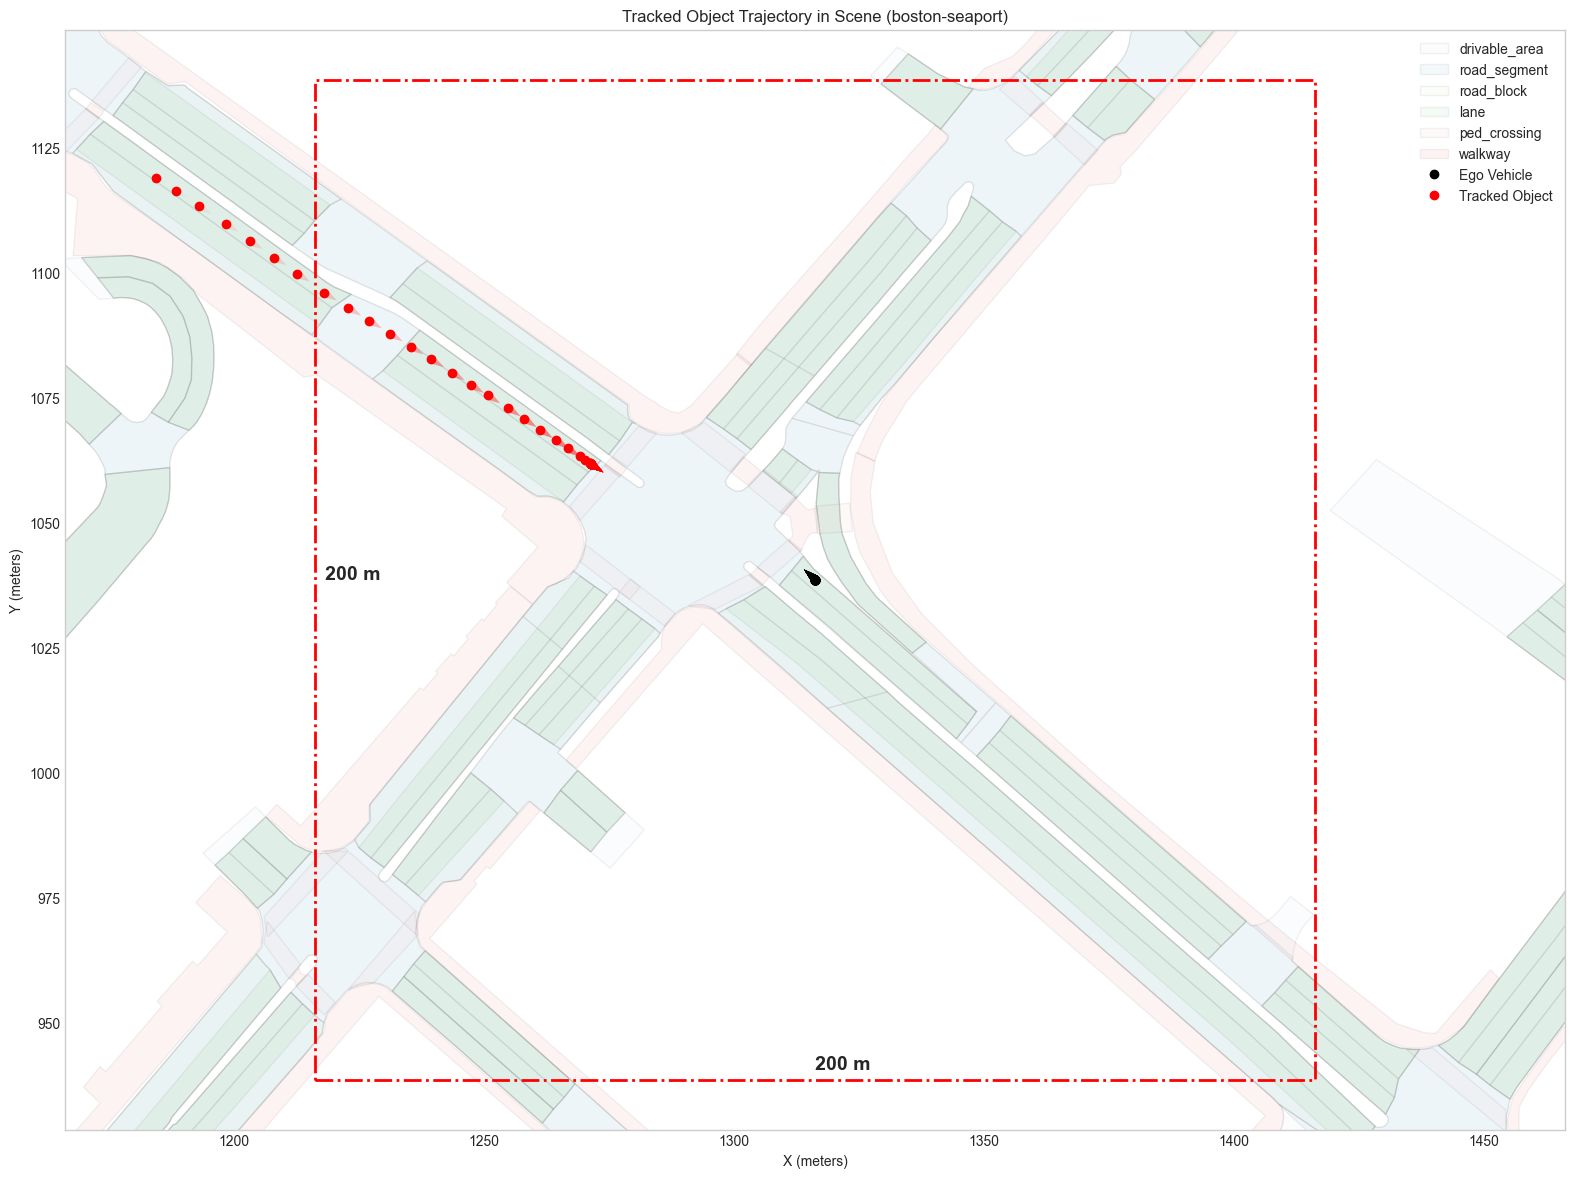

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict, OrderedDict
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

# Toggle to control arrow display (set to False to hide arrows)
show_arrows = True

# Step 1: Load nuScenes dataset
dataroot = "/Users/liliu/Desktop/Nuscenes/nuscenes"  # Adjust this path as needed
nusc = NuScenes(version='v1.0-mini', dataroot=dataroot, verbose=True)

# Step 2: Define the scene and the instance you want to visualize
scene_index = 2  # Adjust this to your scene index
instance_token = "888521a8b57f46258e81a89bf062278b"  # Replace with the actual instance token

# Step 3: Load scene and map
scene = nusc.scene[scene_index]
first_sample_token = scene['first_sample_token']
log = nusc.get("log", scene["log_token"])
location = log["location"]
nusc_map = NuScenesMap(dataroot=dataroot, map_name=location)

# Step 4: Function to convert quaternion to yaw
def quaternion_to_yaw(quaternion):
    q = Quaternion(quaternion)
    return np.arctan2(2.0*(q.w*q.z + q.x*q.y), 1.0 - 2.0*(q.y*q.y + q.z*q.z))

# Step 5: Store trajectories
ego_trajectory = []
ego_orientations = []
timestamps = []
object_trajectory = []
object_orientations = []

# Step 6: Loop through all samples in the scene
sample_token = first_sample_token
while sample_token:
    sample = nusc.get('sample', sample_token)
    timestamps.append(sample['timestamp'])
    
    # Get ego vehicle pose using LIDAR_TOP
    sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
    ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
    ego_trajectory.append(tuple(ego_pose['translation'][:2]))  # X, Y position
    ego_orientations.append(quaternion_to_yaw(ego_pose['rotation']))
    
    # Process all objects in the scene; only consider the specified instance
    for ann_token in sample['anns']:
        ann_data = nusc.get('sample_annotation', ann_token)
        if ann_data['instance_token'] == instance_token:
            object_trajectory.append(tuple(ann_data['translation'][:2]))
            object_orientations.append(quaternion_to_yaw(ann_data['rotation']))
    
    sample_token = sample['next']

# Step 7: Normalize timestamps
timestamps = np.array(timestamps)
timestamps = (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())

# Step 8: Convert lists to NumPy arrays
ego_trajectory = np.array(ego_trajectory)
ego_orientations = np.array(ego_orientations)
object_trajectory = np.array(object_trajectory)
object_orientations = np.array(object_orientations)

# Step 9: Determine map bounds
x_min, y_min = np.min(ego_trajectory, axis=0) - 100
x_max, y_max = np.max(ego_trajectory, axis=0) + 100
map_bounds = (x_min, y_min, x_max, y_max)

# Step 10: Define map layers
layer_names = ["drivable_area", "road_segment", "road_block", "lane", "ped_crossing", "walkway"]

# Step 11: Render the map patch with 50% transparency
fig, ax = nusc_map.render_map_patch(map_bounds, layer_names, alpha=0.05)
ax.set_aspect('equal')

# Step 12: Plot ego vehicle trajectory in black and add arrows (if enabled)
ax.plot(ego_trajectory[:, 0], ego_trajectory[:, 1], 'o', color="black", label="Ego Vehicle")
if show_arrows:
    for i in range(len(ego_trajectory)):
        alpha = timestamps[i]
        dx = 3 * np.cos(ego_orientations[i])
        dy = 3 * np.sin(ego_orientations[i])
        ax.quiver(ego_trajectory[i, 0], ego_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(0,0,0,alpha))

# Step 13: Plot object trajectory in red and add arrows (if enabled)
ax.plot(object_trajectory[:, 0], object_trajectory[:, 1], 'o', color="red", label="Tracked Object")
if show_arrows:
    for i in range(len(object_trajectory)):
        alpha = timestamps[i]
        dx = 3 * np.cos(object_orientations[i])
        dy = 3 * np.sin(object_orientations[i])
        ax.quiver(object_trajectory[i, 0], object_trajectory[i, 1], dx, dy,
                  angles='xy', scale_units='xy', scale=1, color=(1,0,0,alpha))

# Step 14: Labels and legend
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Tracked Object Trajectory in Scene ({location})")
plt.legend()
plt.grid()
plt.show()

In [92]:
object_trajectory - ego_trajectory

array([[-131.8921763 ,   80.40733182],
       [-127.87518958,   77.67733576],
       [-123.32618964,   74.63132905],
       [-117.90519686,   71.14032964],
       [-113.09718565,   67.63831462],
       [-108.3581928 ,   64.40331666],
       [-103.61920113,   61.16632038],
       [ -98.28020171,   57.34831767],
       [ -93.40721312,   54.33632513],
       [ -89.26321477,   51.75832424],
       [ -85.11321294,   49.17632055],
       [ -80.96921756,   46.59832295],
       [ -76.82420716,   44.01931218],
       [ -72.69220753,   41.41031116],
       [ -68.84621341,   38.96231532],
       [ -65.5692186 ,   36.89631914],
       [ -61.47120893,   34.31230971],
       [ -58.24820379,   32.15630439],
       [ -55.02221184,   29.99731094],
       [ -51.79920325,   27.84130273],
       [ -49.50021045,   26.23730869],
       [ -47.16721336,   24.68931089],
       [ -46.11721946,   23.99631597],
       [ -45.06921676,   23.30431327],
       [ -45.08721808,   23.30131413],
       [ -45.00722352,   

In [51]:
ego_trajectory

array([[1316.3781763 , 1038.59366818],
       [1316.37818958, 1038.59366424],
       [1316.37818964, 1038.59367095],
       [1316.37819686, 1038.59367036],
       [1316.37818565, 1038.59368538],
       [1316.3781928 , 1038.59368334],
       [1316.37820113, 1038.59367962],
       [1316.37820171, 1038.59368233],
       [1316.37821312, 1038.59367487],
       [1316.37821477, 1038.59367576],
       [1316.37821294, 1038.59367945],
       [1316.37821756, 1038.59367705],
       [1316.37820716, 1038.59368782],
       [1316.37820753, 1038.59368884],
       [1316.37821341, 1038.59368468],
       [1316.3782186 , 1038.59368086],
       [1316.37820893, 1038.59369029],
       [1316.37820379, 1038.59369561],
       [1316.37821184, 1038.59368906],
       [1316.37820325, 1038.59369727],
       [1316.37821045, 1038.59369131],
       [1316.37821336, 1038.59368911],
       [1316.37821946, 1038.59368403],
       [1316.37821676, 1038.59368673],
       [1316.37821808, 1038.59368587],
       [1316.37822352, 10

In [52]:
object_trajectory

array([[1184.486, 1119.001],
       [1188.503, 1116.271],
       [1193.052, 1113.225],
       [1198.473, 1109.734],
       [1203.281, 1106.232],
       [1208.02 , 1102.997],
       [1212.759, 1099.76 ],
       [1218.098, 1095.942],
       [1222.971, 1092.93 ],
       [1227.115, 1090.352],
       [1231.265, 1087.77 ],
       [1235.409, 1085.192],
       [1239.554, 1082.613],
       [1243.686, 1080.004],
       [1247.532, 1077.556],
       [1250.809, 1075.49 ],
       [1254.907, 1072.906],
       [1258.13 , 1070.75 ],
       [1261.356, 1068.591],
       [1264.579, 1066.435],
       [1266.878, 1064.831],
       [1269.211, 1063.283],
       [1270.261, 1062.59 ],
       [1271.309, 1061.898],
       [1271.291, 1061.895],
       [1271.371, 1061.84 ],
       [1271.479, 1061.766],
       [1271.497, 1061.793],
       [1271.479, 1061.766],
       [1271.461, 1061.739],
       [1271.461, 1061.739],
       [1271.461, 1061.739],
       [1271.461, 1061.739],
       [1271.461, 1061.739],
       [1271.4

In [68]:
np.max(object_trajectory[0,:]) - np.min(object_trajectory[0,:])

65.48500000000013

In [69]:
np.max(object_trajectory[1,:]) - np.min(object_trajectory[1,:])

72.23199999999997

In [42]:
instance_frame.relative_movements

[(-1164.393020051422, -1010.9304913296056),
 (-1169.2094146374698, -1011.5619203542169),
 (-1174.6326605112515, -1012.314563107114),
 (-1181.0033054746998, -1013.3136183991537),
 (-1186.9265156615354, -1013.8793258725525),
 (-1192.6145411088726, -1014.6300516247304),
 (-1198.3074844795312, -1015.3594753253781),
 (-1204.8388501942848, -1016.0545960919436),
 (-1210.480638324175, -1017.0532209085388),
 (-1215.288241735408, -1017.8880471092237),
 (-1220.1044202519874, -1018.7166311354644),
 (-1224.9111963962216, -1019.5564942691766),
 (-1229.7234683559882, -1020.3761031296018),
 (-1234.5422913196007, -1021.1818165688035),
 (-1239.0415561674486, -1021.9154132405009),
 (-1242.8627767493895, -1022.552227695887),
 (-1247.6422562444359, -1023.3454698860826),
 (-1251.4837485207372, -1023.8760708389292),
 (-1255.3275541859316, -1024.4148796240909),
 (-1259.170131168839, -1024.9409515090836),
 (-1261.952874565818, -1025.279158098754),
 (-1264.7254731045934, -1025.6734047973396),
 (-1265.9700300085

In [44]:
xs = [x for x, y in instance_frame.relative_movements]
ys = [y for x, y in instance_frame.relative_movements]

In [45]:
np.max(xs), np.min(xs), np.max(ys), np.min(ys)

(-1164.393020051422,
 -1267.4316228482464,
 -1010.9304913296056,
 -1026.0823701701063)

In [46]:
np.max(xs) - np.min(xs)

103.03860279682453

In [48]:
np.max(ys) - np.min(ys)

15.151878840500672

In [49]:
instance_frame.scene_ego_positions

{1535489296.047917: (1316.3781762981437, 1038.5936681848448),
 1535489296.547795: (1316.3781895837858, 1038.5936642356623),
 1535489297.047675: (1316.378189636131, 1038.5936709470902),
 1535489297.547543: (1316.3781968638182, 1038.5936703559403),
 1535489298.047428: (1316.378185650685, 1038.5936853755643),
 1535489298.547291: (1316.3781927982718, 1038.5936833361334),
 1535489299.047201: (1316.3782011261528, 1038.5936796189335),
 1535489299.547057: (1316.3782017058331, 1038.5936823255845),
 1535489300.046941: (1316.3782131163682, 1038.5936748748054),
 1535489300.546798: (1316.378214774106, 1038.5936757550835),
 1535489301.047243: (1316.3782129414512, 1038.593679451032),
 1535489301.547107: (1316.3782175649947, 1038.5936770483931),
 1535489302.046988: (1316.378207161358, 1038.5936878228056),
 1535489302.547429: (1316.3782075295119, 1038.593688843136),
 1535489303.047308: (1316.3782134064172, 1038.5936846776954),
 1535489303.447089: (1316.3782185976354, 1038.5936808641623),
 1535489303.94

In [56]:
instance_frame.locations

[array([151.98515625,  27.66317686]),
 array([147.16876166,  27.03174783]),
 array([141.74551579,  26.27910508]),
 array([135.37487082,  25.28004979]),
 array([129.45166064,  24.71434231]),
 array([123.76363519,  23.96361656]),
 array([118.07069182,  23.23419286]),
 array([111.5393261 ,  22.53907209]),
 array([105.89753797,  21.54044728]),
 array([101.08993456,  20.70562108]),
 array([96.27375605, 19.87703705]),
 array([91.4669799 , 19.03717392]),
 array([86.65470794, 18.21756506]),
 array([81.83588498, 17.41185162]),
 array([77.33662013, 16.67825494]),
 array([73.51539955, 16.04144049]),
 array([68.73592005, 15.2481983 ]),
 array([64.89442778, 14.71759735]),
 array([61.05062211, 14.17878856]),
 array([57.20804513, 13.65271668]),
 array([54.42530173, 13.31451009]),
 array([51.65270319, 12.92026339]),
 array([50.40814629, 12.7375645 ]),
 array([49.16531998, 12.55789745]),
 array([49.17698511, 12.57110903]),
 array([49.08196468, 12.55441633]),
 array([48.95110447, 12.54164274]),
 array([

In [57]:
instance_frame.orientations

[-2.9503601940881854,
 -2.950357291443405,
 -2.9503763168735047,
 -2.9852886287203377,
 -2.950255818715919,
 -2.950369374112466,
 -2.9677763372437185,
 -2.9503609247384834,
 -2.9504398847466518,
 -2.9504579503867636,
 -2.9504029815031982,
 -2.9504741306426374,
 -2.950322711417427,
 -2.967812616151884,
 -2.990956478032087,
 -2.994564977716365,
 -2.999032381955101,
 -3.00349294529481,
 -3.0080891969019676,
 -3.0124638405528943,
 -3.0126096463832823,
 -3.0126066370426257,
 -3.012636138806047,
 -3.0126121530998438,
 -3.0126242728132597,
 -3.01271954957026,
 -3.012641882121957,
 -3.0126055959136506,
 -3.0126633991225105,
 -3.012634164301259,
 -3.012719063533289,
 -3.012714230064087,
 -3.012661343025517,
 -3.0126713165285706,
 -3.0125818602415193,
 -3.012681830815731,
 -3.012772129006644,
 -3.01278774063767,
 -3.0127364494817175,
 -3.012733046382981,
 -3.0126786682130335]

In [59]:
start_x, start_y = instance_frame.locations[0]
end_x, end_y = instance_frame.locations[-1]

displacement = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)
# Compute direction based on displacement
movement_x = end_x - start_x  # X is right in LiDAR frame
movement_y = end_y - start_y  # Y is forward in LiDAR frame
angle = np.arctan2(movement_y, movement_x)  # Angle relative to LiDAR frame

In [60]:

        # Classify movement based on correct angle ranges
        if np.pi / 3 <= angle <= 2 * np.pi / 3:  # Close to π/2 → Forward
            direction = "moved forward"
        elif 0 <= angle < np.pi / 3:  # Close to 0 → Right
            direction = "moved rightward"
        elif -np.pi / 3 < angle < 0:  # Close to 0 but negative → Slightly right
            direction = "turned slightly right"
        elif 2 * np.pi / 3 < angle <= np.pi or -np.pi <= angle < -2 * np.pi / 3:  # Close to π → Left
            direction = "moved leftward"
        elif -2 * np.pi / 3 <= angle <= -np.pi / 3:  # Close to -π/2 → Backward
            direction = "moved backward"
        else:
            direction = "remained stationary"

In [61]:
angle

-2.996162354380557

In [62]:
movement_y

-15.09128555198009

In [63]:
movement_x

-103.03727554844147

In [65]:
instance_frame.locations

[array([151.98515625,  27.66317686]),
 array([147.16876166,  27.03174783]),
 array([141.74551579,  26.27910508]),
 array([135.37487082,  25.28004979]),
 array([129.45166064,  24.71434231]),
 array([123.76363519,  23.96361656]),
 array([118.07069182,  23.23419286]),
 array([111.5393261 ,  22.53907209]),
 array([105.89753797,  21.54044728]),
 array([101.08993456,  20.70562108]),
 array([96.27375605, 19.87703705]),
 array([91.4669799 , 19.03717392]),
 array([86.65470794, 18.21756506]),
 array([81.83588498, 17.41185162]),
 array([77.33662013, 16.67825494]),
 array([73.51539955, 16.04144049]),
 array([68.73592005, 15.2481983 ]),
 array([64.89442778, 14.71759735]),
 array([61.05062211, 14.17878856]),
 array([57.20804513, 13.65271668]),
 array([54.42530173, 13.31451009]),
 array([51.65270319, 12.92026339]),
 array([50.40814629, 12.7375645 ]),
 array([49.16531998, 12.55789745]),
 array([49.17698511, 12.57110903]),
 array([49.08196468, 12.55441633]),
 array([48.95110447, 12.54164274]),
 array([

In [37]:
object_orientations * 180/np.pi

array([-30.742     , -30.742     , -30.742     , -32.742     ,
       -30.742     , -30.742     , -31.742     , -30.742     ,
       -30.742     , -30.742     , -30.742     , -30.742     ,
       -30.742     , -31.742     , -33.0653687 , -33.27226507,
       -33.53096614, -33.78966358, -34.04864359, -34.30734569,
       -34.30734569, -34.30734569, -34.30734569, -34.30734569,
       -34.30734569, -34.30734569, -34.30734569, -34.30734569,
       -34.30734569, -34.30734569, -34.30734569, -34.30734569,
       -34.30734569, -34.30734569, -34.30734569, -34.30734569,
       -34.30734569, -34.30734569, -34.30734569, -34.30734569,
       -34.30734569])

In [36]:
ego_orientations * 180/np.pi

array([138.30872658, 138.30861665, 138.309785  , 138.31040856,
       138.30302729, 138.30964139, 138.30749903, 138.30995909,
       138.31444428, 138.31529278, 138.31215032, 138.31591422,
       138.30714133, 138.30943981, 138.31255979, 138.31231483,
       138.30953831, 138.3063608 , 138.31067052, 138.30263161,
       138.31076976, 138.31070155, 138.31218152, 138.31092108,
       138.31152262, 138.31703905, 138.31257385, 138.31059819,
       138.31417556, 138.31268749, 138.31758749, 138.31739076,
       138.31436076, 138.31493492, 138.30980876, 138.31557204,
       138.32067414, 138.3218247 , 138.31881355, 138.31863053,
       138.3155113 ])

In [35]:
ego_orientations * 180/np.pi

array([138.30872658, 138.30861665, 138.309785  , 138.31040856,
       138.30302729, 138.30964139, 138.30749903, 138.30995909,
       138.31444428, 138.31529278, 138.31215032, 138.31591422,
       138.30714133, 138.30943981, 138.31255979, 138.31231483,
       138.30953831, 138.3063608 , 138.31067052, 138.30263161,
       138.31076976, 138.31070155, 138.31218152, 138.31092108,
       138.31152262, 138.31703905, 138.31257385, 138.31059819,
       138.31417556, 138.31268749, 138.31758749, 138.31739076,
       138.31436076, 138.31493492, 138.30980876, 138.31557204,
       138.32067414, 138.3218247 , 138.31881355, 138.31863053,
       138.3155113 ])

In [14]:
instance_frame.to_dict()

{'instance_token': '888521a8b57f46258e81a89bf062278b',
 'category_name': 'vehicle.car',
 'instance_name': None,
 'raw_start_time': 1535489296.047917,
 'raw_end_time': 1535489315.948406,
 'ego_vehicle_raw_start_time': 1535489296.047917,
 'start_time': 0.0,
 'end_time': 19.90048909187317,
 'duration': 19.90048909187317,
 'locations': [array([151.98515625,  27.66317686]),
  array([147.16876166,  27.03174783]),
  array([141.74551579,  26.27910508]),
  array([135.37487082,  25.28004979]),
  array([129.45166064,  24.71434231]),
  array([123.76363519,  23.96361656]),
  array([118.07069182,  23.23419286]),
  array([111.5393261 ,  22.53907209]),
  array([105.89753797,  21.54044728]),
  array([101.08993456,  20.70562108]),
  array([96.27375605, 19.87703705]),
  array([91.4669799 , 19.03717392]),
  array([86.65470794, 18.21756506]),
  array([81.83588498, 17.41185162]),
  array([77.33662013, 16.67825494]),
  array([73.51539955, 16.04144049]),
  array([68.73592005, 15.2481983 ]),
  array([64.894427

## previous

In [ ]:
from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion
import os
from nuscenes.nuscenes import NuScenes

class InstanceFrame:
    """ Class to store and process instance frame information from nuScenes dataset. """
    
    def __init__(self, nusc, instance_token, scene_index, scene_ego_positions, ego_vehicle_raw_start_time):
        """
        Initializes an InstanceFrame object and extracts relevant data.

        Args:
            nusc: NuScenes database instance.
            instance_token: The token of the instance to extract.
            scene_index: The index of the scene in nuScenes dataset.
            scene_ego_positions: Precomputed ego vehicle positions for this scene.
            ego_vehicle_raw_start_time: The raw start timestamp of the ego vehicle (in seconds).
        """
        self.nusc = nusc
        self.instance_token = instance_token
        self.scene_index = scene_index  # Scene index for time normalization
        self.scene_ego_positions = scene_ego_positions  # Precomputed ego positions
        self.ego_vehicle_raw_start_time = ego_vehicle_raw_start_time  # New feature

        # Core attributes
        self.category_name = None
        self.instance_name = None  # Assigned based on category count
        self.start_time = None
        self.end_time = None
        self.duration = None
        self.raw_start_time = None  # Pre-normalized start time
        self.raw_end_time = None  # Pre-normalized end time
        self.locations = []
        self.orientations = []
        self.sample_tokens = []
        self.scene_token = None
        self.relative_movements = []  # Stores relative movement to ego vehicle

        # Extract information
        self._extract_instance_data()
        self._normalize_times()
        self._compute_relative_movement()

    def _extract_instance_data(self):
        """ Extract structured Frame representation for the instance in nuScenes. """

        # Get instance details
        instance = self.nusc.get('instance', self.instance_token)
        first_ann_token = instance['first_annotation_token']
        
        # Iterate through all annotations of this instance
        ann = self.nusc.get('sample_annotation', first_ann_token)
        self.category_name = ann['category_name']  # Assign category name

        while ann:
            # Retrieve the sample timestamp
            sample = self.nusc.get('sample', ann['sample_token'])
            timestamp = sample['timestamp'] / 1e6  # Convert to seconds

            # Set start and end time
            if self.start_time is None:
                self.start_time = timestamp
                self.raw_start_time = timestamp  # Store pre-normalized timestamp
                self.scene_token = sample["scene_token"]  # Assign scene

            self.end_time = timestamp  # Keep updating to last timestamp
            self.raw_end_time = timestamp  # Store pre-normalized end timestamp

            # Store location and orientation
            self.locations.append(tuple(ann["translation"][:2]))  # X, Y coordinates
            self.orientations.append(self._quaternion_to_yaw(ann["rotation"]))  # Yaw angle

            # Store sample token for reference
            self.sample_tokens.append(ann["sample_token"])

            # Move to next annotation (if available)
            if ann["next"]:
                ann = self.nusc.get("sample_annotation", ann["next"])
            else:
                break

        # Compute duration
        self.duration = self.end_time - self.start_time

    def _normalize_times(self):
        """ Normalize start and end times relative to the ego vehicle's first timestamp in the scene. """
        # Adjust start and end times so that ego vehicle start time = 0
        self.start_time -= self.ego_vehicle_raw_start_time
        self.end_time -= self.ego_vehicle_raw_start_time

    def _compute_relative_movement(self):
        """ Compute the relative movement of the instance with respect to the ego vehicle using precomputed positions. """
        for i, (timestamp, location) in enumerate(zip(np.linspace(self.start_time, self.end_time, len(self.locations)), self.locations)):
            # Find the closest ego vehicle timestamp
            closest_ego_time = min(self.scene_ego_positions.keys(), key=lambda t: abs(t - timestamp))
            ego_x, ego_y = self.scene_ego_positions[closest_ego_time]
            obj_x, obj_y = location
            rel_x, rel_y = obj_x - ego_x, obj_y - ego_y  # Relative movement

            self.relative_movements.append((rel_x, rel_y))  # Store relative movement

    def describe_movement(self):
        """ Generate a natural language description of the instance's movement relative to the ego vehicle. """
        if len(self.relative_movements) < 2:
            return "Not enough data to describe movement."

        # Compute total displacement
        start_x, start_y = self.relative_movements[0]
        end_x, end_y = self.relative_movements[-1]
        displacement = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)

        # Compute direction based on displacement
        movement_x = end_x - start_x
        movement_y = end_y - start_y
        angle = np.arctan2(movement_y, movement_x)

        # Classify movement based on angle
        if -np.pi / 6 < angle < np.pi / 6:
            direction = "moved forward"
        elif np.pi / 6 <= angle <= np.pi / 2:
            direction = "turned slightly left"
        elif -np.pi / 2 <= angle <= -np.pi / 6:
            direction = "turned slightly right"
        elif angle > np.pi / 2 or angle < -np.pi / 2:
            direction = "moved backward"
        else:
            direction = "remained stationary"

        return f"A {self.category_name} {direction} for {self.duration:.2f} seconds, covering a distance of {displacement:.2f} meters."

    @staticmethod
    def _quaternion_to_yaw(quaternion):
        """ Convert quaternion to yaw angle (rotation around z-axis). """
        q = Quaternion(quaternion)
        return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))

    def to_dict(self):
        """ Converts the instance frame object to a dictionary for easy usage. """
        return {
            "instance_token": self.instance_token,
            "category_name": self.category_name,
            "instance_name": self.instance_name,
            "raw_start_time": self.raw_start_time,  # Pre-normalized start time
            "raw_end_time": self.raw_end_time,  # Pre-normalized end time
            "ego_vehicle_raw_start_time": self.ego_vehicle_raw_start_time,  # New feature
            "start_time": self.start_time,  # Normalized start time
            "end_time": self.end_time,  # Normalized end time
            "duration": self.duration,
            "locations": self.locations,
            "orientations": self.orientations,
            "sample_tokens": self.sample_tokens,
            "scene_token": self.scene_token,
            "description": self.describe_movement()
        }

# Function to precompute ego vehicle positions **once per scene**
def compute_scene_ego_positions(nusc, scene_index):
    scene_ego_positions = {}
    scene = nusc.scene[scene_index]
    first_sample_token = scene['first_sample_token']
    first_sample = nusc.get('sample', first_sample_token)
    ego_vehicle_raw_start_time = first_sample['timestamp'] / 1e6  # Convert to seconds

    sample_token = first_sample_token
    while sample_token:
        sample = nusc.get('sample', sample_token)
        timestamp = sample['timestamp'] / 1e6  # Convert to seconds

        # Get ego vehicle position
        sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Using LiDAR for reference
        ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
        scene_ego_positions[timestamp] = tuple(ego_pose['translation'][:2])

        # Move to the next sample
        sample_token = sample['next']

    return scene_ego_positions, ego_vehicle_raw_start_time

# Example usage:
scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
instance_frame = InstanceFrame(nusc, "some_instance_token", 2, scene_ego_positions, ego_vehicle_raw_start_time)
print(instance_frame.to_dict())  # Print structured instance frame

In [103]:
from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion
import os
from nuscenes.nuscenes import NuScenes

class InstanceFrame:
    """ Class to store and process instance frame information from nuScenes dataset. """
    
    def __init__(self, nusc, instance_token, scene_index, scene_ego_positions, ego_vehicle_raw_start_time):
        """
        Initializes an InstanceFrame object and extracts relevant data.

        Args:
            nusc: NuScenes database instance.
            instance_token: The token of the instance to extract.
            scene_index: The index of the scene in nuScenes dataset.
            scene_ego_positions: Precomputed ego vehicle positions for this scene.
            ego_vehicle_raw_start_time: The raw start timestamp of the ego vehicle (in seconds).
        """
        self.nusc = nusc
        self.instance_token = instance_token
        self.scene_index = scene_index  # Scene index for time normalization
        self.scene_ego_positions = scene_ego_positions  # Precomputed ego positions
        self.ego_vehicle_raw_start_time = ego_vehicle_raw_start_time  # New feature

        # Core attributes
        self.category_name = None
        self.instance_name = None  # Assigned based on category count
        self.start_time = None
        self.end_time = None
        self.duration = None
        self.raw_start_time = None  # Pre-normalized start time
        self.raw_end_time = None  # Pre-normalized end time
        self.locations = []
        self.orientations = []
        self.sample_tokens = []
        self.scene_token = None
        self.relative_movements = []  # Stores relative movement to ego vehicle

        # Extract information
        self._extract_instance_data()
        self._normalize_times()
        self._compute_relative_movement()

    def _extract_instance_data(self):
        """ Extract structured Frame representation for the instance in nuScenes. """

        # Get instance details
        instance = self.nusc.get('instance', self.instance_token)
        first_ann_token = instance['first_annotation_token']
        
        # Iterate through all annotations of this instance
        ann = self.nusc.get('sample_annotation', first_ann_token)
        self.category_name = ann['category_name']  # Assign category name

        while ann:
            # Retrieve the sample timestamp
            sample = self.nusc.get('sample', ann['sample_token'])
            timestamp = sample['timestamp'] / 1e6  # Convert to seconds

            # Set start and end time
            if self.start_time is None:
                self.start_time = timestamp
                self.raw_start_time = timestamp  # Store pre-normalized timestamp
                self.scene_token = sample["scene_token"]  # Assign scene

            self.end_time = timestamp  # Keep updating to last timestamp
            self.raw_end_time = timestamp  # Store pre-normalized end timestamp

            # Store location and orientation
            self.locations.append(tuple(ann["translation"][:2]))  # X, Y coordinates
            self.orientations.append(self._quaternion_to_yaw(ann["rotation"]))  # Yaw angle

            # Store sample token for reference
            self.sample_tokens.append(ann["sample_token"])

            # Move to next annotation (if available)
            if ann["next"]:
                ann = self.nusc.get("sample_annotation", ann["next"])
            else:
                break

        # Compute duration
        self.duration = self.end_time - self.start_time

    def _normalize_times(self):
        """ Normalize start and end times relative to the ego vehicle's first timestamp in the scene. """
        # Adjust start and end times so that ego vehicle start time = 0
        self.start_time -= self.ego_vehicle_raw_start_time
        self.end_time -= self.ego_vehicle_raw_start_time

    def _compute_relative_movement(self):
        """ Compute the relative movement of the instance with respect to the ego vehicle using precomputed positions. """
        for i, (timestamp, location) in enumerate(zip(np.linspace(self.start_time, self.end_time, len(self.locations)), self.locations)):
            # Find the closest ego vehicle timestamp
            closest_ego_time = min(self.scene_ego_positions.keys(), key=lambda t: abs(t - timestamp))
            ego_x, ego_y = self.scene_ego_positions[closest_ego_time]
            obj_x, obj_y = location
            rel_x, rel_y = obj_x - ego_x, obj_y - ego_y  # Relative movement

            self.relative_movements.append((rel_x, rel_y))  # Store relative movement

    def describe_movement(self):
        """ Generate a natural language description of the instance's movement relative to the ego vehicle's heading. """
        
        if len(self.relative_movements) < 2:
            return "Not enough data to describe movement."
    
        # Compute total displacement
        start_x, start_y = self.relative_movements[0]
        end_x, end_y = self.relative_movements[-1]
        displacement = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)
    
        # Get the ego vehicle's yaw angle (heading) at the start time
        closest_ego_time = min(self.scene_ego_positions.keys(), key=lambda t: abs(t - self.start_time))
        ego_start_x, ego_start_y = self.scene_ego_positions[closest_ego_time]
    
        # Get the ego vehicle's orientation (yaw) at the start time
        sample = self.nusc.get('sample', self.sample_tokens[0])  # Get first sample where this instance appears
        sample_data = self.nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Use LiDAR for ego pose
        ego_pose = self.nusc.get('ego_pose', sample_data['ego_pose_token'])
        ego_yaw = self._quaternion_to_yaw(ego_pose['rotation'])  # Ego vehicle's yaw in radians
    
        # Compute movement in the ego vehicle's coordinate frame
        movement_x = end_x - start_x
        movement_y = end_y - start_y
    
        # Rotate movement vector to align with the ego vehicle's heading
        rel_movement_x = movement_x * np.cos(-ego_yaw) - movement_y * np.sin(-ego_yaw)
        rel_movement_y = movement_x * np.sin(-ego_yaw) + movement_y * np.cos(-ego_yaw)
    
        # Classify movement based on relative motion
        if rel_movement_x > 0 and abs(rel_movement_y) < abs(rel_movement_x) * 0.5:
            direction = "moved forward"
        elif rel_movement_x < 0 and abs(rel_movement_y) < abs(rel_movement_x) * 0.5:
            direction = "moved backward"
        elif rel_movement_y > 0:
            direction = "turned left"
        elif rel_movement_y < 0:
            direction = "turned right"
        else:
            direction = "remained stationary"
    
        return f"A {self.category_name} {direction} for {self.duration:.2f} seconds, covering a distance of {displacement:.2f} meters."

    @staticmethod
    def _quaternion_to_yaw(quaternion):
        """ Convert quaternion to yaw angle (rotation around z-axis). """
        q = Quaternion(quaternion)
        return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))

    def to_dict(self):
        """ Converts the instance frame object to a dictionary for easy usage. """
        return {
            "instance_token": self.instance_token,
            "category_name": self.category_name,
            "instance_name": self.instance_name,
            "raw_start_time": self.raw_start_time,  # Pre-normalized start time
            "raw_end_time": self.raw_end_time,  # Pre-normalized end time
            "ego_vehicle_raw_start_time": self.ego_vehicle_raw_start_time,  # New feature
            "start_time": self.start_time,  # Normalized start time
            "end_time": self.end_time,  # Normalized end time
            "duration": self.duration,
            "locations": self.locations,
            "orientations": self.orientations,
            "sample_tokens": self.sample_tokens,
            "scene_token": self.scene_token,
            "description": self.describe_movement()
        }

# Function to precompute ego vehicle positions **once per scene**
def compute_scene_ego_positions(nusc, scene_index):
    scene_ego_positions = {}
    scene = nusc.scene[scene_index]
    first_sample_token = scene['first_sample_token']
    first_sample = nusc.get('sample', first_sample_token)
    ego_vehicle_raw_start_time = first_sample['timestamp'] / 1e6  # Convert to seconds

    sample_token = first_sample_token
    while sample_token:
        sample = nusc.get('sample', sample_token)
        timestamp = sample['timestamp'] / 1e6  # Convert to seconds

        # Get ego vehicle position
        sample_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])  # Using LiDAR for reference
        ego_pose = nusc.get('ego_pose', sample_data['ego_pose_token'])
        scene_ego_positions[timestamp] = tuple(ego_pose['translation'][:2])

        # Move to the next sample
        sample_token = sample['next']

    return scene_ego_positions, ego_vehicle_raw_start_time

# Example usage:
scene_ego_positions, ego_vehicle_raw_start_time = compute_scene_ego_positions(nusc, 2)
instance_frame = InstanceFrame(nusc, "888521a8b57f46258e81a89bf062278b", 2, scene_ego_positions, ego_vehicle_raw_start_time)
print(instance_frame.to_dict())  # Print structured instance frame

{'instance_token': '888521a8b57f46258e81a89bf062278b', 'category_name': 'vehicle.car', 'instance_name': None, 'raw_start_time': 1535489296.047917, 'raw_end_time': 1535489315.948406, 'ego_vehicle_raw_start_time': 1535489296.047917, 'start_time': 0.0, 'end_time': 19.90048909187317, 'duration': 19.90048909187317, 'locations': [(1184.486, 1119.001), (1188.503, 1116.271), (1193.052, 1113.225), (1198.473, 1109.734), (1203.281, 1106.232), (1208.02, 1102.997), (1212.759, 1099.76), (1218.098, 1095.942), (1222.971, 1092.93), (1227.115, 1090.352), (1231.265, 1087.77), (1235.409, 1085.192), (1239.554, 1082.613), (1243.686, 1080.004), (1247.532, 1077.556), (1250.809, 1075.49), (1254.907, 1072.906), (1258.13, 1070.75), (1261.356, 1068.591), (1264.579, 1066.435), (1266.878, 1064.831), (1269.211, 1063.283), (1270.261, 1062.59), (1271.309, 1061.898), (1271.291, 1061.895), (1271.371, 1061.84), (1271.479, 1061.766), (1271.497, 1061.793), (1271.479, 1061.766), (1271.461, 1061.739), (1271.461, 1061.739), (

In [107]:
print(instance_frame.to_dict().keys())

dict_keys(['instance_token', 'category_name', 'instance_name', 'raw_start_time', 'raw_end_time', 'ego_vehicle_raw_start_time', 'start_time', 'end_time', 'duration', 'locations', 'orientations', 'sample_tokens', 'scene_token', 'description'])


In [108]:
instance_frame.to_dict()

{'instance_token': '888521a8b57f46258e81a89bf062278b',
 'category_name': 'vehicle.car',
 'instance_name': None,
 'raw_start_time': 1535489296.047917,
 'raw_end_time': 1535489315.948406,
 'ego_vehicle_raw_start_time': 1535489296.047917,
 'start_time': 0.0,
 'end_time': 19.90048909187317,
 'duration': 19.90048909187317,
 'locations': [(1184.486, 1119.001),
  (1188.503, 1116.271),
  (1193.052, 1113.225),
  (1198.473, 1109.734),
  (1203.281, 1106.232),
  (1208.02, 1102.997),
  (1212.759, 1099.76),
  (1218.098, 1095.942),
  (1222.971, 1092.93),
  (1227.115, 1090.352),
  (1231.265, 1087.77),
  (1235.409, 1085.192),
  (1239.554, 1082.613),
  (1243.686, 1080.004),
  (1247.532, 1077.556),
  (1250.809, 1075.49),
  (1254.907, 1072.906),
  (1258.13, 1070.75),
  (1261.356, 1068.591),
  (1264.579, 1066.435),
  (1266.878, 1064.831),
  (1269.211, 1063.283),
  (1270.261, 1062.59),
  (1271.309, 1061.898),
  (1271.291, 1061.895),
  (1271.371, 1061.84),
  (1271.479, 1061.766),
  (1271.497, 1061.793),
  (1

In [104]:
instance_frame.relative_movements

[(-131.89217629814357, 80.4073318151552),
 (-127.87517629814374, 77.67733181515518),
 (-123.32617629814376, 74.63133181515514),
 (-117.90517629814372, 71.14033181515515),
 (-113.09717629814372, 67.6383318151552),
 (-108.35817629814369, 64.4033318151553),
 (-103.61917629814366, 61.16633181515522),
 (-98.28017629814372, 57.348331815155234),
 (-93.40717629814367, 54.33633181515529),
 (-89.26317629814366, 51.758331815155316),
 (-85.11317629814357, 49.17633181515521),
 (-80.96917629814357, 46.598331815155234),
 (-76.82417629814358, 44.01933181515528),
 (-72.69217629814375, 41.41033181515513),
 (-68.84617629814375, 38.96233181515527),
 (-65.5691762981437, 36.896331815155236),
 (-61.471176298143746, 34.312331815155176),
 (-58.24817629814356, 32.15633181515523),
 (-55.02217629814368, 29.99733181515512),
 (-51.79917629814372, 27.841331815155172),
 (-49.50017629814374, 26.23733181515513),
 (-47.16717629814366, 24.68933181515513),
 (-46.117176298143704, 23.996331815155145),
 (-45.0691762981437, 2

In [97]:
instance_frame.to_dict()['ego_vehicle_raw_start_time']

1535489296.047917

In [98]:
instance_frame.to_dict()['raw_start_time']

1535489296.047917

In [100]:
instance_frame.scene_ego_positions

{1535489296.047917: (1316.3781762981437, 1038.5936681848448),
 1535489296.547795: (1316.3781895837858, 1038.5936642356623),
 1535489297.047675: (1316.378189636131, 1038.5936709470902),
 1535489297.547543: (1316.3781968638182, 1038.5936703559403),
 1535489298.047428: (1316.378185650685, 1038.5936853755643),
 1535489298.547291: (1316.3781927982718, 1038.5936833361334),
 1535489299.047201: (1316.3782011261528, 1038.5936796189335),
 1535489299.547057: (1316.3782017058331, 1038.5936823255845),
 1535489300.046941: (1316.3782131163682, 1038.5936748748054),
 1535489300.546798: (1316.378214774106, 1038.5936757550835),
 1535489301.047243: (1316.3782129414512, 1038.593679451032),
 1535489301.547107: (1316.3782175649947, 1038.5936770483931),
 1535489302.046988: (1316.378207161358, 1038.5936878228056),
 1535489302.547429: (1316.3782075295119, 1038.593688843136),
 1535489303.047308: (1316.3782134064172, 1038.5936846776954),
 1535489303.447089: (1316.3782185976354, 1038.5936808641623),
 1535489303.94

In [93]:
ego_vehicle_start_time

1535489296047917

In [90]:
instance_frame.start_time

0.0

In [92]:
instance_frame.to_dict()['raw_start_time']

1535489296.047917

In [91]:
instance_frame.to_dict()['description']

'A vehicle.car turned slightly right for 19.90 seconds, covering a distance of 104.13 meters.'

In [32]:
# Get instance details
instance = nusc.get('instance', instance_token)

# Get first and last annotation of the instance
first_ann_token = instance['first_annotation_token']
ann = nusc.get('sample_annotation', first_ann_token)

# Initialize timestamps
first_timestamp = None
last_timestamp = None

# Iterate through the annotation chain to find timestamps
while ann:
    # Retrieve the sample timestamp for this annotation
    sample = nusc.get('sample', ann['sample_token'])
    timestamp = sample['timestamp'] / 1e6  # Convert from microseconds to seconds

    # Set first and last timestamps
    if first_timestamp is None:
        first_timestamp = timestamp
    last_timestamp = timestamp

    # Move to next annotation (if available)
    if ann['next'] != '':
        ann = nusc.get('sample_annotation', ann['next'])
    else:
        break


# Compute duration
duration = last_timestamp - first_timestamp

# print(f"Instance {instance_token} appears from {first_timestamp:.2f}s to {last_timestamp:.2f}s")
print(f"Total duration: {duration:.2f}s")

Total duration: 19.90s


In [34]:
from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion

def quaternion_to_yaw(quaternion):
    """ Convert quaternion to yaw angle (rotation around z-axis). """
    q = Quaternion(quaternion)
    return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))

def extract_instance_frames(nusc, instance_token):
    """ Extract structured Frame representation for a given instance in nuScenes. """

    # Get instance details
    instance = nusc.get('instance', instance_token)
  
    first_ann_token = instance['first_annotation_token']

    # Initialize frame structure
    frame = {
        "instance_token": instance_token,
        "category_name": category_name,
        "instance_name": None,  # Will be assigned based on category count
        "start_time": None,
        "end_time": None,
        "duration": None,
        "locations": [],
        "orientations": [],
        "sample_tokens": [],
        "scene_token": None
    }

    # Iterate through all annotations of this instance
    ann = nusc.get('sample_annotation', first_ann_token)
    frame['category_name'] = ann['category_name']
    while ann:
        # Retrieve the sample timestamp
        sample = nusc.get('sample', ann['sample_token'])
        timestamp = sample['timestamp'] / 1e6  # Convert to seconds

        # Set start and end time
        if frame["start_time"] is None:
            frame["start_time"] = timestamp
            frame["scene_token"] = sample["scene_token"]  # Assign scene

        frame["end_time"] = timestamp  # Keep updating to last timestamp

        # Store location and orientation
        frame["locations"].append(tuple(ann["translation"][:2]))  # X, Y coordinates
        frame["orientations"].append(quaternion_to_yaw(ann["rotation"]))  # Yaw angle

        # Store sample token for reference
        frame["sample_tokens"].append(ann["sample_token"])

        # Move to next annotation (if available)
        if ann["next"]:
            ann = nusc.get("sample_annotation", ann["next"])
        else:
            break

    # Compute duration
    frame["duration"] = frame["end_time"] - frame["start_time"]

    return frame

# Example usage:
instance_frames = extract_instance_frames(nusc, instance_token)
print(instance_frames)

{'instance_token': 'b61b72a5b5ad482e9bc94c203f75b8d4', 'category_name': 'human.pedestrian.adult', 'instance_name': None, 'start_time': 1535489296.047917, 'end_time': 1535489315.948406, 'duration': 19.90048909187317, 'locations': [(1295.125, 1032.757), (1295.611, 1033.251), (1296.187, 1033.665), (1296.747, 1033.991), (1297.316, 1034.301), (1298.023, 1034.652), (1298.55, 1034.966), (1299.077, 1035.28), (1299.604, 1035.594), (1300.131, 1035.908), (1300.747, 1036.155), (1301.363, 1036.401), (1301.978, 1036.647), (1302.594, 1036.893), (1303.21, 1037.14), (1303.636, 1037.423), (1304.162, 1037.787), (1304.68, 1038.163), (1305.186, 1038.556), (1305.691, 1038.948), (1306.121, 1039.385), (1306.524, 1039.795), (1306.928, 1040.207), (1307.332, 1040.617), (1307.735, 1041.028), (1308.096, 1041.419), (1308.497, 1041.852), (1308.898, 1042.285), (1309.299, 1042.718), (1309.7, 1043.152), (1310.03, 1043.691), (1310.28, 1044.143), (1310.666, 1044.526), (1311.053, 1044.909), (1311.466, 1045.234), (1311.859

In [35]:
instance_frames

{'instance_token': 'b61b72a5b5ad482e9bc94c203f75b8d4',
 'category_name': 'human.pedestrian.adult',
 'instance_name': None,
 'start_time': 1535489296.047917,
 'end_time': 1535489315.948406,
 'duration': 19.90048909187317,
 'locations': [(1295.125, 1032.757),
  (1295.611, 1033.251),
  (1296.187, 1033.665),
  (1296.747, 1033.991),
  (1297.316, 1034.301),
  (1298.023, 1034.652),
  (1298.55, 1034.966),
  (1299.077, 1035.28),
  (1299.604, 1035.594),
  (1300.131, 1035.908),
  (1300.747, 1036.155),
  (1301.363, 1036.401),
  (1301.978, 1036.647),
  (1302.594, 1036.893),
  (1303.21, 1037.14),
  (1303.636, 1037.423),
  (1304.162, 1037.787),
  (1304.68, 1038.163),
  (1305.186, 1038.556),
  (1305.691, 1038.948),
  (1306.121, 1039.385),
  (1306.524, 1039.795),
  (1306.928, 1040.207),
  (1307.332, 1040.617),
  (1307.735, 1041.028),
  (1308.096, 1041.419),
  (1308.497, 1041.852),
  (1308.898, 1042.285),
  (1309.299, 1042.718),
  (1309.7, 1043.152),
  (1310.03, 1043.691),
  (1310.28, 1044.143),
  (1310

In [36]:
from collections import defaultdict, OrderedDict
import numpy as np
from pyquaternion import Quaternion

class InstanceFrame:
    """ Class to store and process instance frame information from nuScenes dataset. """
    
    def __init__(self, nusc, instance_token):
        """
        Initializes an InstanceFrame object and extracts relevant data.
        
        Args:
            nusc: NuScenes database instance.
            instance_token: The token of the instance to extract.
        """
        self.nusc = nusc
        self.instance_token = instance_token
        
        # Core attributes
        self.category_name = None
        self.instance_name = None  # Will be assigned later
        self.start_time = None
        self.end_time = None
        self.duration = None
        self.locations = []
        self.orientations = []
        self.sample_tokens = []
        self.scene_token = None

        # Extract information
        self._extract_instance_data()

    def _extract_instance_data(self):
        """ Extracts structured Frame representation for the instance in nuScenes. """

        # Get instance details
        instance = self.nusc.get('instance', self.instance_token)
        first_ann_token = instance['first_annotation_token']
        
        # Iterate through all annotations of this instance
        ann = self.nusc.get('sample_annotation', first_ann_token)
        self.category_name = ann['category_name']  # Assign category name

        while ann:
            # Retrieve the sample timestamp
            sample = self.nusc.get('sample', ann['sample_token'])
            timestamp = sample['timestamp'] / 1e6  # Convert to seconds

            # Set start and end time
            if self.start_time is None:
                self.start_time = timestamp
                self.scene_token = sample["scene_token"]  # Assign scene

            self.end_time = timestamp  # Keep updating to last timestamp

            # Store location and orientation
            self.locations.append(tuple(ann["translation"][:2]))  # X, Y coordinates
            self.orientations.append(self._quaternion_to_yaw(ann["rotation"]))  # Yaw angle

            # Store sample token for reference
            self.sample_tokens.append(ann["sample_token"])

            # Move to next annotation (if available)
            if ann["next"]:
                ann = self.nusc.get("sample_annotation", ann["next"])
            else:
                break

        # Compute duration
        self.duration = self.end_time - self.start_time

    @staticmethod
    def _quaternion_to_yaw(quaternion):
        """ Convert quaternion to yaw angle (rotation around z-axis). """
        q = Quaternion(quaternion)
        return np.arctan2(2.0 * (q.w * q.z + q.x * q.y), 1.0 - 2.0 * (q.y * q.y + q.z * q.z))

    def to_dict(self):
        """ Converts the instance frame object to a dictionary for easy usage. """
        return {
            "instance_token": self.instance_token,
            "category_name": self.category_name,
            "instance_name": self.instance_name,
            "start_time": self.start_time,
            "end_time": self.end_time,
            "duration": self.duration,
            "locations": self.locations,
            "orientations": self.orientations,
            "sample_tokens": self.sample_tokens,
            "scene_token": self.scene_token
        }

# Example usage:
instance_frame = InstanceFrame(nusc, instance_token)
print(instance_frame.to_dict())  # Print structured instance frame

{'instance_token': 'b61b72a5b5ad482e9bc94c203f75b8d4', 'category_name': 'human.pedestrian.adult', 'instance_name': None, 'start_time': 1535489296.047917, 'end_time': 1535489315.948406, 'duration': 19.90048909187317, 'locations': [(1295.125, 1032.757), (1295.611, 1033.251), (1296.187, 1033.665), (1296.747, 1033.991), (1297.316, 1034.301), (1298.023, 1034.652), (1298.55, 1034.966), (1299.077, 1035.28), (1299.604, 1035.594), (1300.131, 1035.908), (1300.747, 1036.155), (1301.363, 1036.401), (1301.978, 1036.647), (1302.594, 1036.893), (1303.21, 1037.14), (1303.636, 1037.423), (1304.162, 1037.787), (1304.68, 1038.163), (1305.186, 1038.556), (1305.691, 1038.948), (1306.121, 1039.385), (1306.524, 1039.795), (1306.928, 1040.207), (1307.332, 1040.617), (1307.735, 1041.028), (1308.096, 1041.419), (1308.497, 1041.852), (1308.898, 1042.285), (1309.299, 1042.718), (1309.7, 1043.152), (1310.03, 1043.691), (1310.28, 1044.143), (1310.666, 1044.526), (1311.053, 1044.909), (1311.466, 1045.234), (1311.859

In [43]:
instance_frame.category_name

'human.pedestrian.adult'

In [27]:
ann.keys()

dict_keys(['token', 'sample_token', 'instance_token', 'visibility_token', 'attribute_tokens', 'translation', 'size', 'rotation', 'prev', 'next', 'num_lidar_pts', 'num_radar_pts', 'category_name'])

In [ ]:
# Plot only the selected top 10 objects with unique colors and shapes

for i, instance in enumerate(selected_instances):
    category = object_categories[instance]

for instance_token in selected_instances:
    trajectory = np.array(filtered_trajectories[instance_token])
    orientations = np.array(filtered_orientations[instance_token])
    category = object_categories[instance_token]

    for i in range(len(trajectory)):
        alpha = timestamps[i]